# Weighted GNN com pesos nas arestas — Kernel Gaussiano

Notebook mínimo para treinar uma GNN cujos pesos das arestas são definidos pelo **kernel Gaussiano (RBF)**:

$$w_{ij} = \exp\left(-\frac{\lVert x_i - x_j \rVert_2^2}{2\sigma^2}\right),$$

onde $x_i$ e $x_j$ são as coordenadas dos nós e $\sigma$ é o parâmetro de escala do kernel.

## Por que Gaussiano ao invés de Exponencial?

O kernel Gaussiano apresenta um **decaimento mais suave** em relação à distância, comparado à exponencial $e^{-d}$. Isso significa que:

- **Nós muito próximos** (distância pequena) recebem pesos próximos a 1
- **Nós médios** (distância moderada) recebem pesos intermediários de forma gradual
- **Nós distantes** (distância grande) recebem pesos próximos a zero

O parâmetro $\sigma$ controla a "suavidade" do decaimento: **valores maiores fazem o kernel decair mais lentamente** (maior influência de nós distantes), enquanto valores menores criam uma queda mais abrupta.

A topologia é construída por **k-vizinhos mais próximos** e a matriz ponderada é normalizada com a normalização simétrica $D^{-1/2}AD^{-1/2}$ antes da propagação.


## 1. Bibliotecas e caminhos

In [1]:
import copy
import itertools
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from IPython.display import display
from sklearn.neighbors import NearestNeighbors


# Funciona tanto com o Jupyter iniciado na raiz quanto em Notebooks/.
project_dir = Path.cwd().resolve()
if project_dir.name.lower() == "notebooks":
    project_dir = project_dir.parent

src_dir = project_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from Data.feature_extraction import (
    daily_precip_dataset_to_tensor,
    daily_temp_features,
    daily_vertical_velocity,
    forecast_steps_to_daily_precip,
    get_temp,
    get_vv,
    station_dictionary,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2. Carregamento e preparação dos dados

In [2]:
start_date = "2024-01-01"
end_date = "2025-05-31"

catalog_dir = project_dir / "Datasets" / "dados_inmet"
catalog_files = sorted(catalog_dir.glob("Catalogo*.csv"))
if not catalog_files:
    raise FileNotFoundError(f"Catálogo de estações não encontrado em {catalog_dir}")

catalogo_inmet = pd.read_csv(catalog_files[0], sep=";")
estacoes_RS = station_dictionary(catalogo_inmet)
estacoes = list(estacoes_RS.keys())

coords = np.asarray(
    [[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
    dtype=np.float32,
)
N = len(estacoes)

nc_dir = project_dir / "Datasets" / "nc_files"
rea_tp = xr.open_dataset(nc_dir / "era5_precipitation_80-26.nc").sel(
    time=slice(start_date, end_date)
)
rea_temp = xr.open_dataset(nc_dir / "temp_05-25.nc").sel(
    time=slice(start_date, end_date)
)
rea_vv = xr.open_dataset(nc_dir / "era5_vv_06-25.nc").sel(
    time=slice(start_date, end_date)
)

vv_daily_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset = forecast_steps_to_daily_precip(
    rea_tp,
    to_mm=True,
).isel(time=slice(None, -1))

T = (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1
X_tp = daily_precip_dataset_to_tensor(
    tp_daily_dataset,
    stations=estacoes_RS,
).reshape(T, N, 1)
X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

print(f"Período: {start_date} a {end_date}")
print(f"Número de nós: {N}")

Período: 2024-01-01 a 2025-05-31
Número de nós: 62


## 3. Grade de hiperparâmetros e divisão dos nós

In [31]:
SEED = 42
node_index = 32
patience = 1000
min_delta = 1e-4

# Grade editável de hiperparâmetros.
hyperparameter_grid = {
    "k": [61],
    "epochs": [2000],
    "hidden_dim": [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096],
    "n_hidden_layers": [2],
    "learning_rate": [1e-3, 1e-4, 1e-5],
}

target_date = "2025-01-12"

# Target_dates: 

# Muita chuva: 12/05/2024
# Média chuva: 17/01/2024
# Pouca chuva: 12/01/2025
# Zero chuva: 08/02/2025

In [32]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

target_timestamp = pd.Timestamp(target_date)
if not pd.Timestamp(start_date) <= target_timestamp <= pd.Timestamp(end_date):
    raise ValueError("target_date está fora do período carregado.")

t_idx = (target_timestamp - pd.Timestamp(start_date)).days
X = torch.stack(
    [X_vv[t_idx, :, 0], X_t[t_idx, :, 0]],
    dim=-1,
).float()
y = X_tp[t_idx, :, 0].float()

generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(N, generator=generator)
n_train = int(round(0.70 * N))
n_val = int(round(0.10 * N))

idx_train = permutation[:n_train]
idx_val = permutation[n_train:n_train + n_val]
idx_test = permutation[n_train + n_val:]


def make_mask(indices, size):
    mask = torch.zeros(size, dtype=torch.bool)
    mask[indices] = True
    return mask


mask_train = make_mask(idx_train, N)
mask_val = make_mask(idx_val, N)
mask_test = make_mask(idx_test, N)

X = X.to(device)
y = y.to(device)
mask_train = mask_train.to(device)
mask_val = mask_val.to(device)
mask_test = mask_test.to(device)

print(
    f"Treino: {mask_train.sum().item()} | "
    f"Validação: {mask_val.sum().item()} | "
    f"Teste: {mask_test.sum().item()}"
)

Treino: 43 | Validação: 6 | Teste: 13


## 4. Grafo ponderado com Kernel Gaussiano

A matriz binária define apenas a topologia k-NN. Para cada aresta existente, o peso bruto é calculado usando o kernel Gaussiano:

**Referência**: Belkin, M., & Niyogi, P. (2003). "Laplacian Eigenmaps for Dimensionality Reduction and Data Representation." Neural Computation.

$$w_{ij} = \exp\left(-\frac{\lVert x_i-x_j\rVert_2^2}{2\sigma^2}\right)$$

Os auto-laços recebem peso 1 e, em seguida, é aplicada a normalização simétrica $D^{-1/2}AD^{-1/2}$.

In [33]:
def build_weighted_adjacency(coordinates, n_neighbors, sigma=1.0):
    """Constrói A e D^(-1/2) A D^(-1/2) com kernel Gaussiano: w_ij = exp(-||x_i-x_j||^2 / (2*sigma^2))."""
    coordinates = np.asarray(coordinates, dtype=np.float32)
    n_nodes = coordinates.shape[0]

    if not 1 <= n_neighbors < n_nodes:
        raise ValueError(f"k deve estar entre 1 e {n_nodes - 1}.")

    neighbors = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coordinates)
    _, neighbor_indices = neighbors.kneighbors(coordinates)
    neighbor_indices = neighbor_indices[:, 1:]

    adjacency_binary = torch.zeros((n_nodes, n_nodes), dtype=torch.bool)
    for i, indices in enumerate(neighbor_indices):
        adjacency_binary[i, torch.as_tensor(indices, dtype=torch.long)] = True

    # Grafo não direcionado: basta que i escolha j ou j escolha i.
    adjacency_binary = adjacency_binary | adjacency_binary.T
    adjacency_binary.fill_diagonal_(False)

    coordinates_tensor = torch.as_tensor(coordinates, dtype=torch.float32)
    distances = torch.cdist(coordinates_tensor, coordinates_tensor, p=2)
    
    # Kernel Gaussiano: w_ij = exp(-(d_ij^2) / (2*sigma^2))
    sigma_squared = sigma ** 2
    adjacency_weighted = torch.zeros_like(distances)
    adjacency_weighted[adjacency_binary] = torch.exp(
        -(distances[adjacency_binary] ** 2) / (2.0 * sigma_squared)
    )
    adjacency_weighted.fill_diagonal_(1.0)

    degree = adjacency_weighted.sum(dim=1).clamp_min(1e-12)
    inv_sqrt_degree = degree.rsqrt()
    adjacency_normalized = (
        inv_sqrt_degree[:, None]
        * adjacency_weighted
        * inv_sqrt_degree[None, :]
    )

    if not torch.isfinite(adjacency_normalized).all():
        raise FloatingPointError("A matriz ponderada contém valores não finitos.")

    return adjacency_weighted, adjacency_normalized


print("Regra de peso da grade: w_ij = exp(-||x_i - x_j||_2^2 / (2*sigma^2)) [Kernel Gaussiano]")

Regra de peso da grade: w_ij = exp(-||x_i - x_j||_2^2 / (2*sigma^2)) [Kernel Gaussiano]


## 4.1. Self-Tuning Spectral Clustering (Adaptativo)

Ao invés de usar um único $\sigma$ global, o **self-tuning** calcula um $\sigma_i$ **diferente para cada nó** baseado na sua vizinhança local:

$$\sigma_i = d_{i,k}$$

onde $d_{i,k}$ é a distância do nó $i$ até seu k-ésimo vizinho mais próximo.

### Vantagem

Em regiões com **diferentes densidades** de nós:
- Nós em regiões densas: $\sigma$ pequeno (peso concentrado nos vizinhos próximos)
- Nós em regiões esparsas: $\sigma$ grande (peso mais distribuído)

Isso **torna o método robusto** a variações de densidade nos dados.

### Referência

**Zelnik-Manor, L., & Perona, P. (2004).** "Self-Tuning Spectral Clustering." NIPS.


In [34]:
def compute_self_tuning_sigma(coordinates, n_neighbors):
    """
    Calcula sigma_i = d_{i,k} para cada nó (Self-Tuning Spectral Clustering).
    
    Referência: Zelnik-Manor, L., & Perona, P. (2004). "Self-Tuning Spectral Clustering." NIPS.
    
    Args:
        coordinates: array (n_nodes, 2) com coordenadas dos nós
        n_neighbors: k para k-vizinhos mais próximos
    
    Returns:
        sigma_array: array (n_nodes,) com sigma_i para cada nó
    """
    coordinates = np.asarray(coordinates, dtype=np.float32)
    n_nodes = coordinates.shape[0]
    
    if not 1 <= n_neighbors < n_nodes:
        raise ValueError(f"k deve estar entre 1 e {n_nodes - 1}.")
    
    neighbors = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coordinates)
    distances, _ = neighbors.kneighbors(coordinates)
    distances = distances[:, 1:]  # Exclui o próprio nó
    
    # sigma_i = distância para o k-ésimo vizinho
    sigma_array = distances[:, -1]  # Último (k-ésimo) vizinho
    
    return sigma_array


def build_weighted_adjacency_selftuning(coordinates, n_neighbors, sigma_array=None):
    """
    Constrói A e D^(-1/2) A D^(-1/2) com kernel Gaussiano com self-tuning.
    
    Se sigma_array for None, usa sigma_i = d_{i,k} (self-tuning).
    Caso contrário, usa os sigmas fornecidos.
    
    Args:
        coordinates: array (n_nodes, 2)
        n_neighbors: k para k-vizinhos mais próximos
        sigma_array: array (n_nodes,) com sigma para cada nó. Se None, computa self-tuning.
    
    Returns:
        adjacency_weighted: matriz ponderada antes da normalização
        adjacency_normalized: matriz ponderada normalizada D^{-1/2}AD^{-1/2}
        sigma_array: array de sigmas utilizados
    """
    coordinates = np.asarray(coordinates, dtype=np.float32)
    n_nodes = coordinates.shape[0]
    
    if not 1 <= n_neighbors < n_nodes:
        raise ValueError(f"k deve estar entre 1 e {n_nodes - 1}.")
    
    # Computa self-tuning se não fornecido
    if sigma_array is None:
        sigma_array = compute_self_tuning_sigma(coordinates, n_neighbors)
    else:
        sigma_array = np.asarray(sigma_array, dtype=np.float32)
    
    neighbors = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coordinates)
    _, neighbor_indices = neighbors.kneighbors(coordinates)
    neighbor_indices = neighbor_indices[:, 1:]
    
    adjacency_binary = torch.zeros((n_nodes, n_nodes), dtype=torch.bool)
    for i, indices in enumerate(neighbor_indices):
        adjacency_binary[i, torch.as_tensor(indices, dtype=torch.long)] = True
    
    adjacency_binary = adjacency_binary | adjacency_binary.T
    adjacency_binary.fill_diagonal_(False)
    
    coordinates_tensor = torch.as_tensor(coordinates, dtype=torch.float32)
    distances = torch.cdist(coordinates_tensor, coordinates_tensor, p=2)
    
    # Kernel Gaussiano com sigmas por nó: w_ij = exp(-(d_ij^2) / (2*sigma_i*sigma_j))
    # Usa média geométrica: sqrt(sigma_i * sigma_j)
    sigma_tensor = torch.as_tensor(sigma_array, dtype=torch.float32)
    sigma_product = torch.outer(sigma_tensor, sigma_tensor)  # sigma_i * sigma_j
    sigma_geometric_mean = torch.sqrt(sigma_product)  # sqrt(sigma_i * sigma_j)
    
    adjacency_weighted = torch.zeros_like(distances)
    adjacency_weighted[adjacency_binary] = torch.exp(
        -(distances[adjacency_binary] ** 2) / (2.0 * sigma_geometric_mean[adjacency_binary] ** 2)
    )
    adjacency_weighted.fill_diagonal_(1.0)
    
    degree = adjacency_weighted.sum(dim=1).clamp_min(1e-12)
    inv_sqrt_degree = degree.rsqrt()
    adjacency_normalized = (
        inv_sqrt_degree[:, None]
        * adjacency_weighted
        * inv_sqrt_degree[None, :]
    )
    
    if not torch.isfinite(adjacency_normalized).all():
        raise FloatingPointError("A matriz ponderada contém valores não finitos.")
    
    return adjacency_weighted, adjacency_normalized, sigma_array


print("✓ Funções de self-tuning carregadas!")
print("  - compute_self_tuning_sigma(coordinates, n_neighbors)")
print("  - build_weighted_adjacency_selftuning(coordinates, n_neighbors, sigma_array=None)")


✓ Funções de self-tuning carregadas!
  - compute_self_tuning_sigma(coordinates, n_neighbors)
  - build_weighted_adjacency_selftuning(coordinates, n_neighbors, sigma_array=None)


## 5. Modelo

In [35]:
class WeightedGNN(nn.Module):
    """GNN densa com agregação pela adjacência ponderada normalizada."""

    def __init__(self, in_dim, hidden_dim, n_hidden_layers, out_dim=1):
        super().__init__()
        if n_hidden_layers < 1:
            raise ValueError("n_hidden_layers deve ser pelo menos 1.")

        self.hidden_layers = nn.ModuleList(
            [nn.Linear(in_dim, hidden_dim)]
            + [
                nn.Linear(hidden_dim, hidden_dim)
                for _ in range(n_hidden_layers - 1)
            ]
        )
        self.output_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, features, adjacency_normalized):
        hidden = features
        for layer in self.hidden_layers:
            hidden = adjacency_normalized @ hidden
            hidden = F.relu(layer(hidden))
        return self.output_layer(hidden).squeeze(-1)

## 6. Busca em grade com early stopping

In [36]:
import itertools


def train_weighted_gnn(
    features,
    targets,
    adjacency_normalized,
    train_mask,
    val_mask,
    test_mask,
    epochs_value,
    hidden_dim_value,
    n_hidden_layers_value,
    learning_rate_value,
    patience_value,
    min_delta_value,
    seed=42,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = WeightedGNN(
        in_dim=features.shape[1],
        hidden_dim=hidden_dim_value,
        n_hidden_layers=n_hidden_layers_value,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate_value,
    )
    loss_function = nn.MSELoss(reduction="mean")

    history = {"train": [], "validation": [], "test": []}
    best_validation = float("inf")
    best_epoch = 0
    stop_epoch = epochs_value
    patience_counter = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs_value + 1):
        model.train()
        optimizer.zero_grad()
        predictions = model(features, adjacency_normalized)
        train_loss = loss_function(predictions[train_mask], targets[train_mask])
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            predictions = model(features, adjacency_normalized)
            validation_loss = loss_function(
                predictions[val_mask], targets[val_mask]
            )
            test_loss = loss_function(predictions[test_mask], targets[test_mask])

        history["train"].append(train_loss.item())
        history["validation"].append(validation_loss.item())
        history["test"].append(test_loss.item())

        if validation_loss.item() < best_validation - min_delta_value:
            best_validation = validation_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience_value:
            stop_epoch = epoch
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        predictions = model(features, adjacency_normalized)
        final_losses = {
            "Treino": loss_function(
                predictions[train_mask], targets[train_mask]
            ).item(),
            "Validação": loss_function(
                predictions[val_mask], targets[val_mask]
            ).item(),
            "Teste": loss_function(
                predictions[test_mask], targets[test_mask]
            ).item(),
        }

    return model, predictions, history, final_losses, best_epoch, stop_epoch


grid_names = list(hyperparameter_grid)
grid_combinations = list(
    itertools.product(*(hyperparameter_grid[name] for name in grid_names))
)

grid_rows = []
grid_histories = {}
grid_predictions_by_config = {}
grid_predictions_by_hidden_dim = {}
graph_cache = {}
best_run = None

print(f"Total de configurações: {len(grid_combinations)}")

for run_number, combination in enumerate(grid_combinations, start=1):
    config = dict(zip(grid_names, combination))
    k_value = config["k"]

    if k_value not in graph_cache:
        weighted, normalized = build_weighted_adjacency(
            coords,
            n_neighbors=k_value,
            sigma=1.0,  # Parâmetro de escala do kernel Gaussiano
        )
        graph_cache[k_value] = {
            "weighted": weighted,
            "normalized": normalized.to(device),
        }

    model_run, predictions_run, history_run, losses_run, best_epoch_run, stop_epoch_run = (
        train_weighted_gnn(
            X,
            y,
            graph_cache[k_value]["normalized"],
            mask_train,
            mask_val,
            mask_test,
            epochs_value=config["epochs"],
            hidden_dim_value=config["hidden_dim"],
            n_hidden_layers_value=config["n_hidden_layers"],
            learning_rate_value=config["learning_rate"],
            patience_value=patience,
            min_delta_value=min_delta,
            seed=SEED,
        )
    )

    grid_predictions_by_hidden_dim[config["hidden_dim"]] = (
        predictions_run.detach().cpu().numpy()
    )

    history_key = tuple(config[name] for name in grid_names)
    grid_histories[history_key] = history_run
    grid_predictions_by_config[history_key] = predictions_run.detach().cpu().numpy()

    row = {
        **config,
        "best_epoch": best_epoch_run,
        "stop_epoch": stop_epoch_run,
        "loss_train": losses_run["Treino"],
        "loss_validation": losses_run["Validação"],
        "loss_test": losses_run["Teste"],
    }
    grid_rows.append(row)

    if best_run is None or row["loss_validation"] < best_run["loss_validation"]:
        best_run = {
            **row,
            "model": model_run,
            "predictions": predictions_run.detach().clone(),
            "history": history_run,
        }

    print(
        f"[{run_number:02d}/{len(grid_combinations)}] "
        f"k={config['k']}, epochs={config['epochs']}, "
        f"hidden={config['hidden_dim']} -> "
        f"val={losses_run['Validação']:.6f}"
    )

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values("loss_validation")
    .reset_index(drop=True)
)

# Variáveis da melhor configuração para as células seguintes.
model = best_run["model"]
predictions = best_run["predictions"]
history = best_run["history"]
best_epoch = best_run["best_epoch"]
stop_epoch = best_run["stop_epoch"]
best_k = best_run["k"]
A_weighted = graph_cache[best_k]["weighted"]
A_norm_weighted = graph_cache[best_k]["normalized"]

print("\nMelhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())


Total de configurações: 36
[01/36] k=61, epochs=2000, hidden=2 -> val=0.067099
[02/36] k=61, epochs=2000, hidden=2 -> val=0.067157
[03/36] k=61, epochs=2000, hidden=2 -> val=0.585577
[04/36] k=61, epochs=2000, hidden=4 -> val=0.067050
[05/36] k=61, epochs=2000, hidden=4 -> val=0.067381
[06/36] k=61, epochs=2000, hidden=4 -> val=3.689507
[07/36] k=61, epochs=2000, hidden=8 -> val=0.066678
[08/36] k=61, epochs=2000, hidden=8 -> val=0.069652
[09/36] k=61, epochs=2000, hidden=8 -> val=1.347544
[10/36] k=61, epochs=2000, hidden=16 -> val=0.067330
[11/36] k=61, epochs=2000, hidden=16 -> val=0.070411
[12/36] k=61, epochs=2000, hidden=16 -> val=0.085527
[13/36] k=61, epochs=2000, hidden=32 -> val=0.062833
[14/36] k=61, epochs=2000, hidden=32 -> val=0.067802
[15/36] k=61, epochs=2000, hidden=32 -> val=0.067817
[16/36] k=61, epochs=2000, hidden=64 -> val=0.063735
[17/36] k=61, epochs=2000, hidden=64 -> val=0.067411
[18/36] k=61, epochs=2000, hidden=64 -> val=0.070673
[19/36] k=61, epochs=2000, h

## 7. Resultados da grade e melhor execução

In [37]:
def node_split(index):
    if mask_train[index].item():
        return "Treino"
    if mask_val[index].item():
        return "Validação"
    return "Teste"


print("Resultados da grade, ordenados pela loss de validação:")
display(grid_results.style.format(precision=6))

node_result = pd.DataFrame(
    [{
        "Nó": node_index,
        "Estação": estacoes[node_index],
        "Conjunto": node_split(node_index),
        "Valor verdadeiro": y[node_index].item(),
        "Valor predito": predictions[node_index].item(),
        "Erro absoluto": abs(
            predictions[node_index].item() - y[node_index].item()
        ),
    }]
)

print("Melhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())

print("\nDetalhes da melhor execução:")
print(
    f"k={best_run['k']}, hidden_dim={best_run['hidden_dim']}, "
    f"epochs={best_run['epochs']}, lr={best_run['learning_rate']}, "
    f"loss_val={best_run['loss_validation']:.6f}"
)

# Matrizes referentes ao melhor valor de k encontrado.
torch.set_printoptions(
    threshold=float("inf"),
    linewidth=200,
    precision=6,
    sci_mode=False,
)

print(f"Matriz de adjacência ponderada da melhor configuração (k={best_k}):")
print(A_weighted.cpu())

print("Matriz de adjacência ponderada normalizada:")
print(A_norm_weighted.cpu())

Resultados da grade, ordenados pela loss de validação:


,k,epochs,hidden_dim,n_hidden_layers,learning_rate,best_epoch,stop_epoch,loss_train,loss_validation,loss_test
0,61,2000,4096,2,0.000010,1446,2000,0.166760,0.058438,0.153480
1,61,2000,4096,2,0.000100,921,1921,0.169158,0.058482,0.153349
2,61,2000,2048,2,0.000100,832,1832,0.170640,0.058722,0.157548
3,61,2000,2048,2,0.000010,1695,2000,0.168586,0.058898,0.156011
4,61,2000,1024,2,0.000100,933,1933,0.170606,0.059062,0.157277
5,61,2000,4096,2,0.001000,666,1666,0.178469,0.059281,0.160738
6,61,2000,512,2,0.001000,1417,2000,0.165060,0.059311,0.150181
7,61,2000,512,2,0.000100,1407,2000,0.168400,0.059982,0.155812
8,61,2000,256,2,0.000100,1703,2000,0.172049,0.061388,0.159041
9,61,2000,256,2,0.001000,1073,2000,0.170051,0.062060,0.157305


Melhor configuração pela loss de validação:
k                    61.000000
epochs             2000.000000
hidden_dim         4096.000000
n_hidden_layers       2.000000
learning_rate         0.000010
best_epoch         1446.000000
stop_epoch         2000.000000
loss_train            0.166760
loss_validation       0.058438
loss_test             0.153480

Detalhes da melhor execução:
k=61, hidden_dim=4096, epochs=2000, lr=1e-05, loss_val=0.058438
Matriz de adjacência ponderada da melhor configuração (k=61):
tensor([[1.000000, 0.035686, 0.865428, 0.845587, 0.000898, 0.333978, 0.088907, 0.001772, 0.000007, 0.000834, 0.000192, 0.327079, 0.000375, 0.000079, 0.007208, 0.004295, 0.603871, 0.115533, 0.000027,
         0.000035, 0.766352, 0.003358, 0.609872, 0.000042, 0.025435, 0.002911, 0.004708, 0.000292, 0.010343, 0.000296, 0.731794, 0.003178, 0.002493, 0.021932, 0.145762, 0.029758, 0.000186, 0.091617,
         0.000456, 0.000335, 0.188538, 0.211979, 0.374952, 0.233781, 0.020388, 0.000293, 0.0

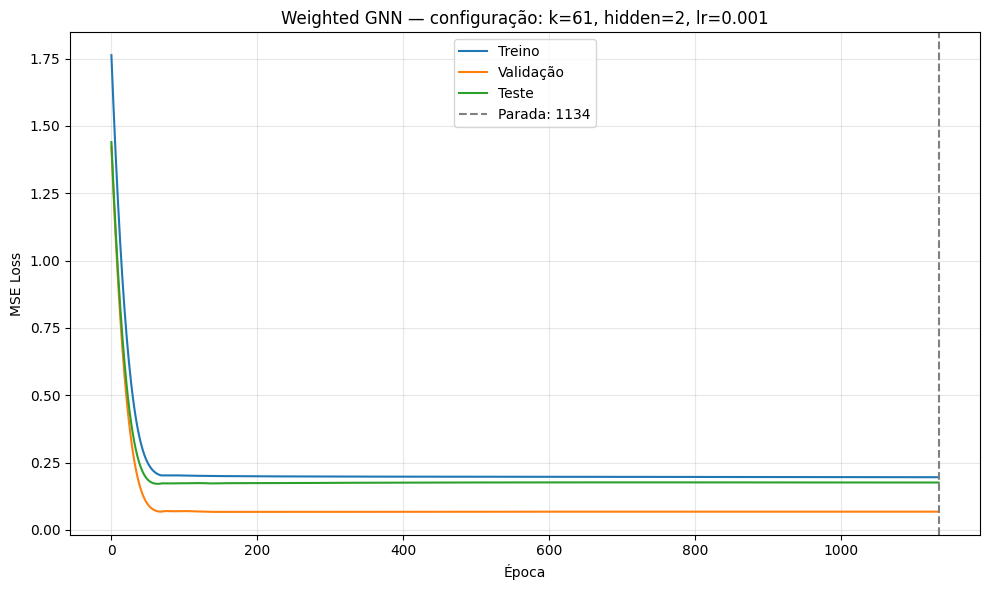

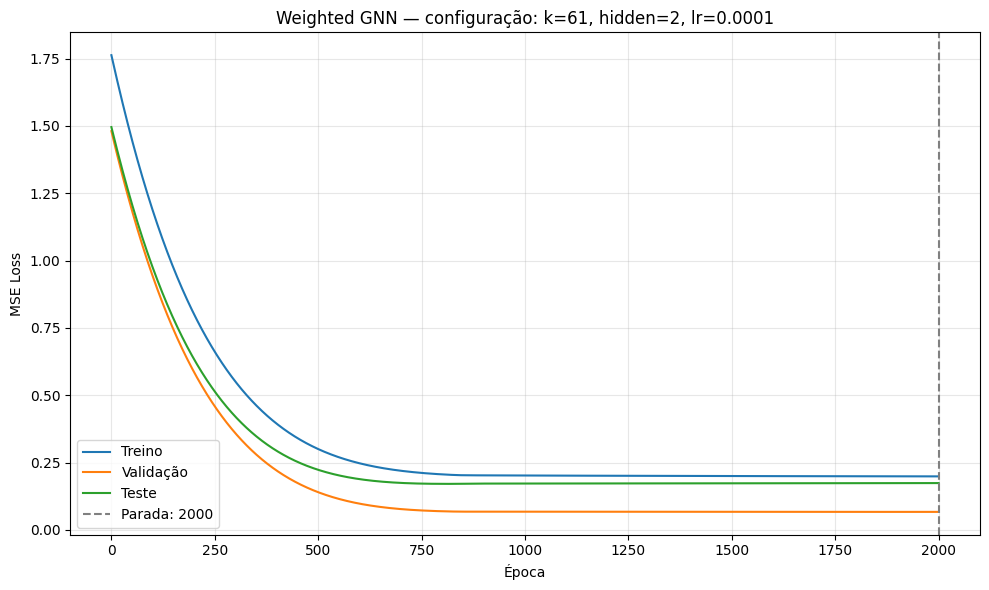

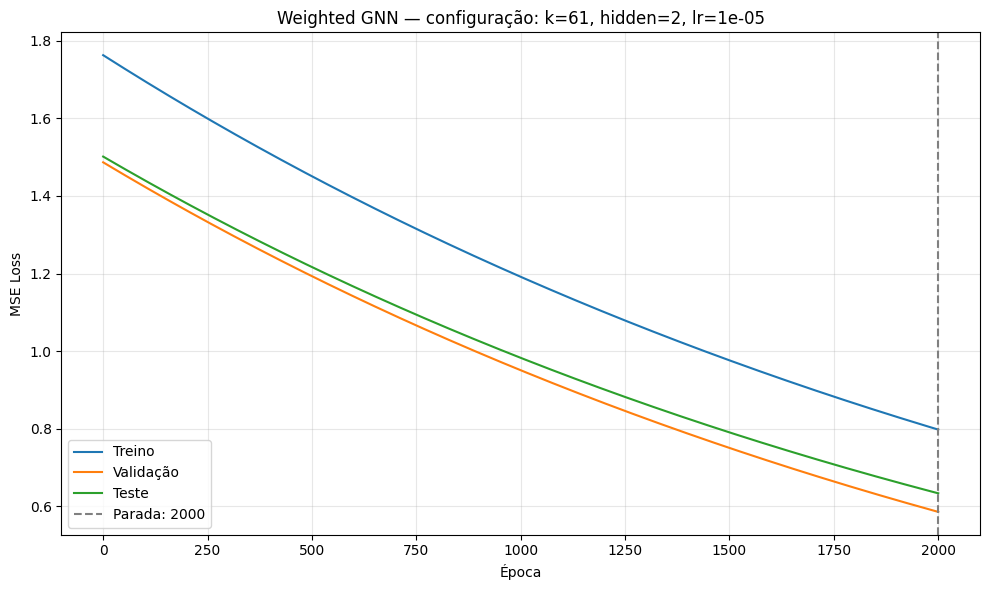

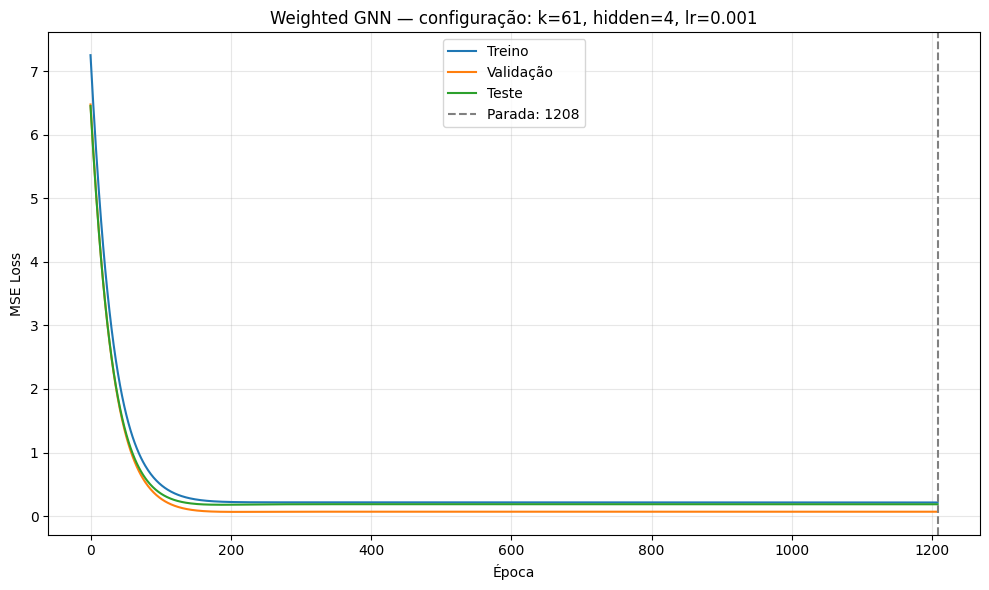

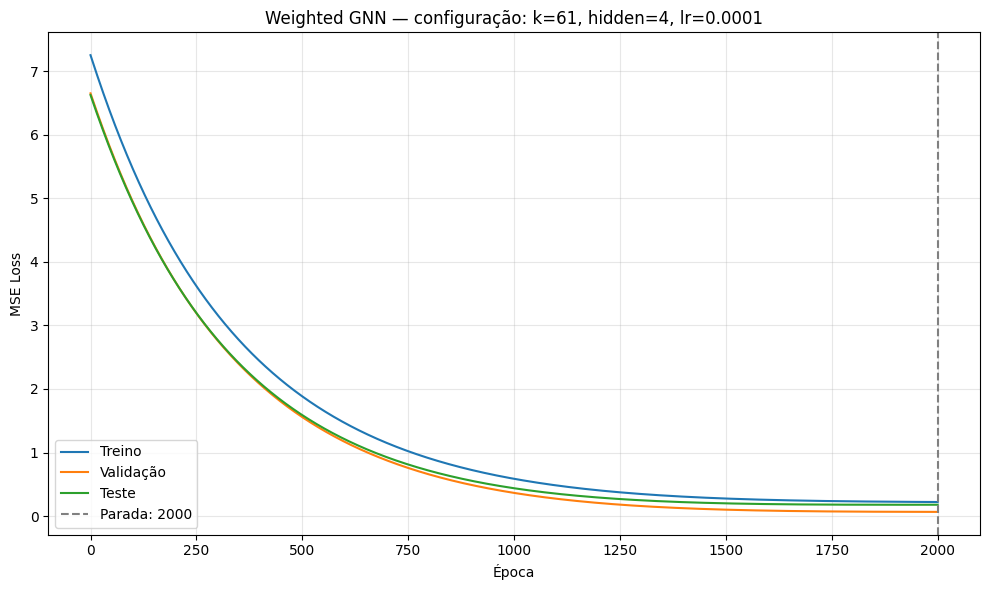

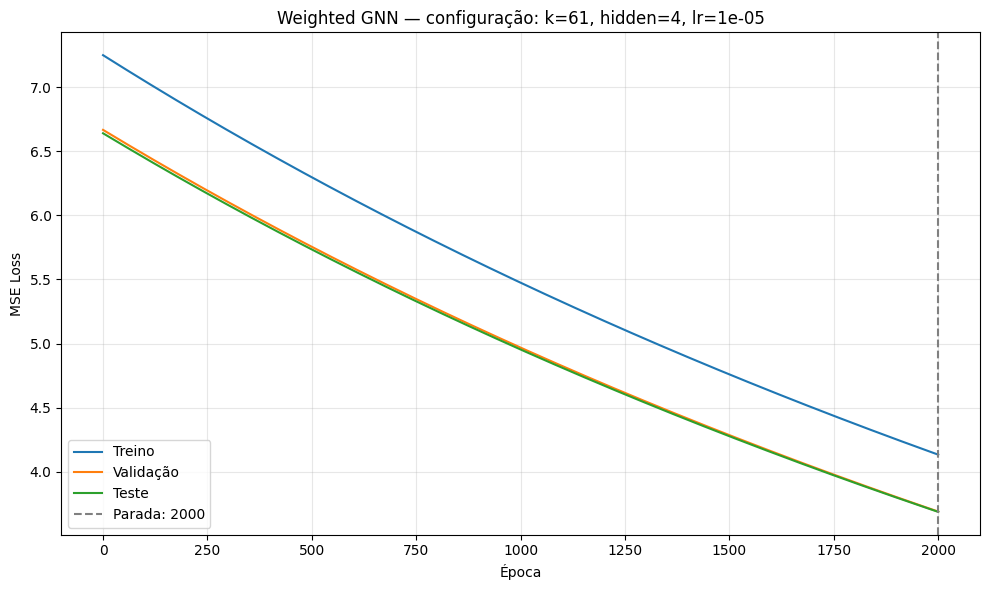

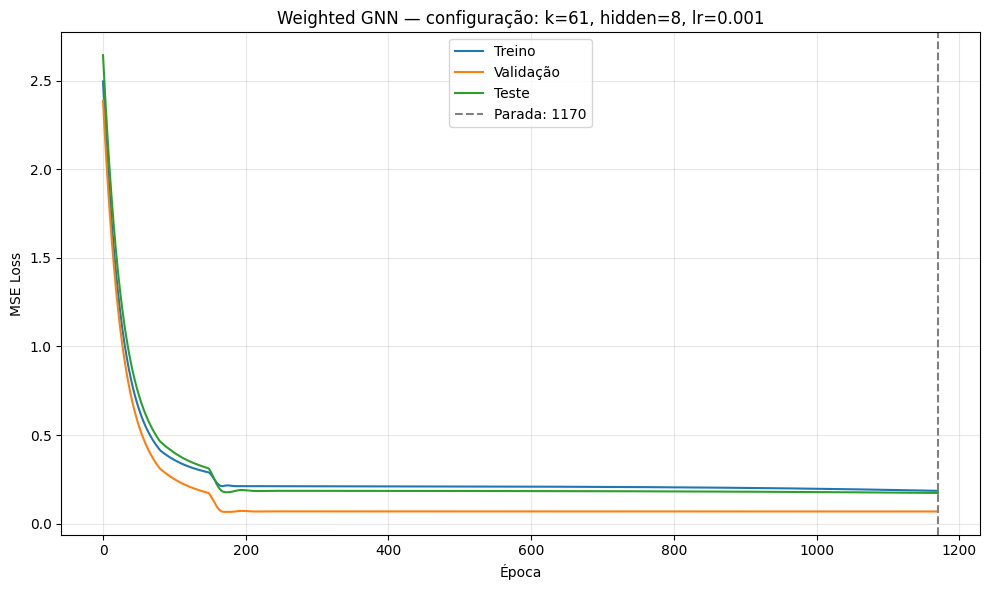

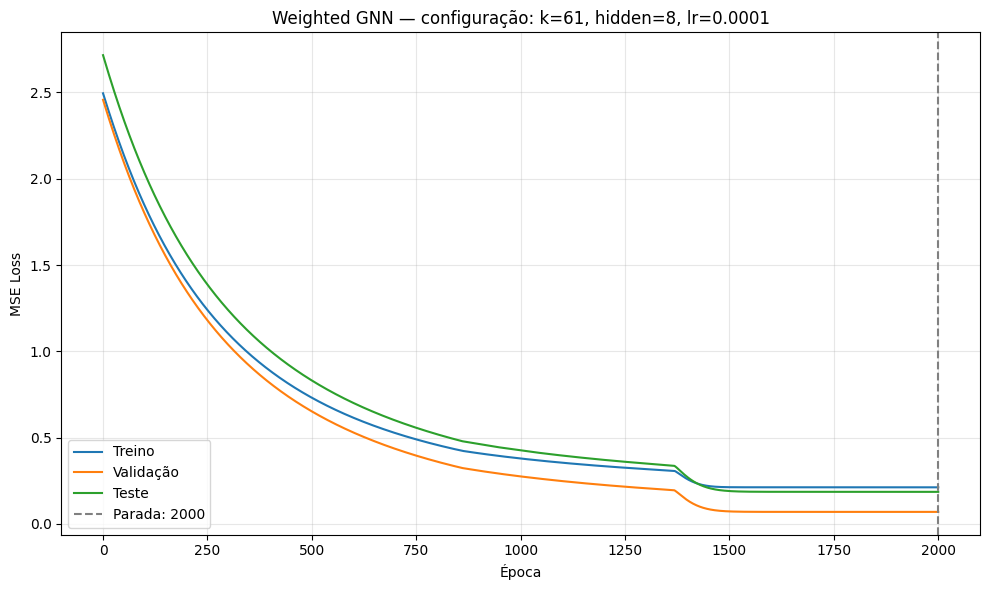

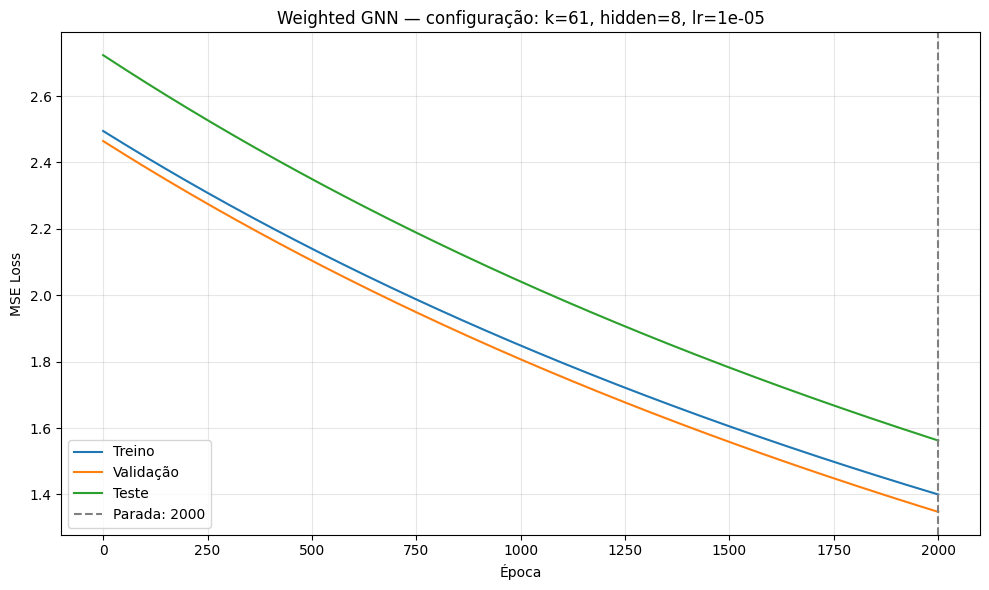

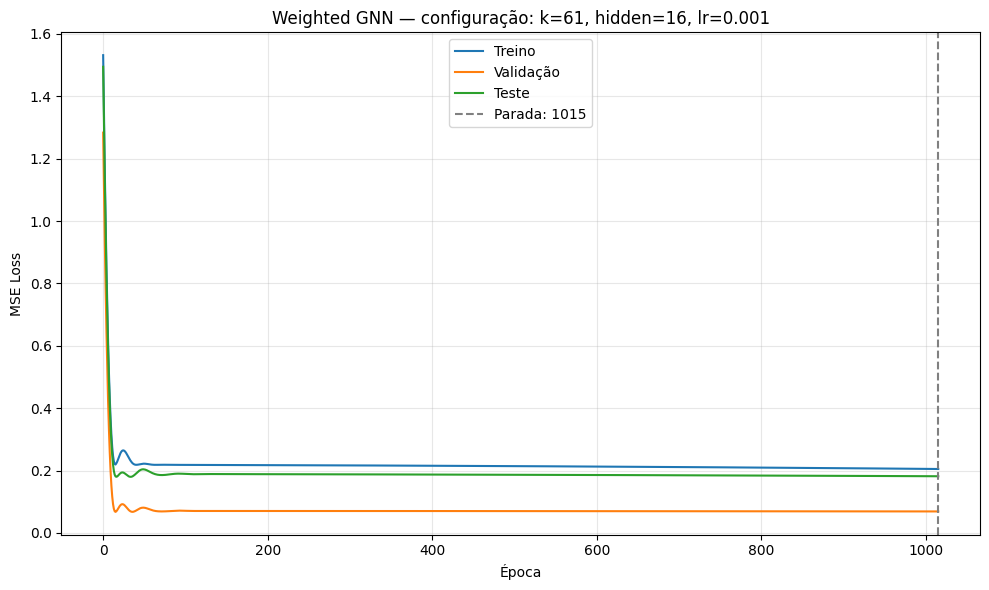

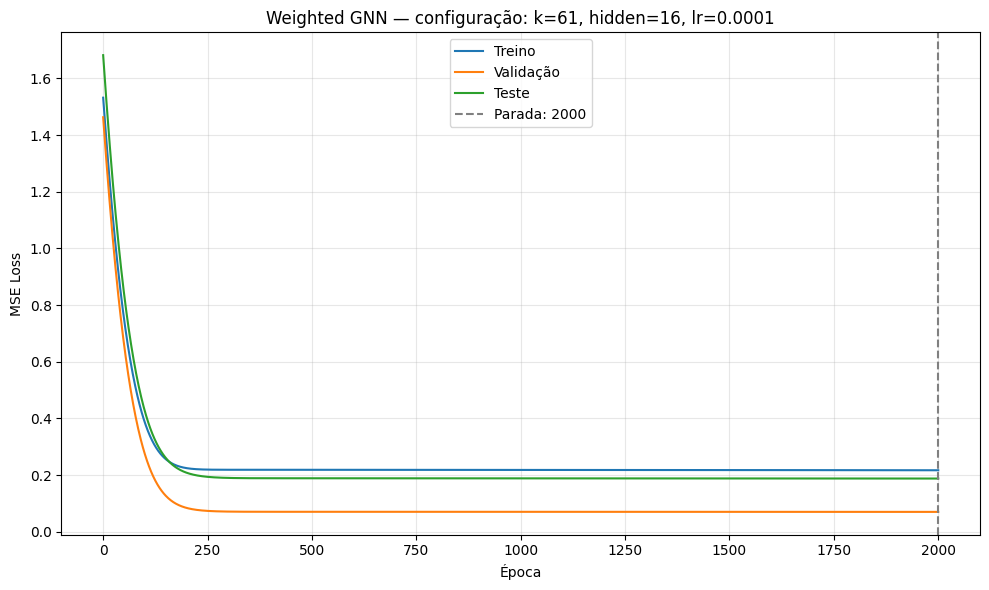

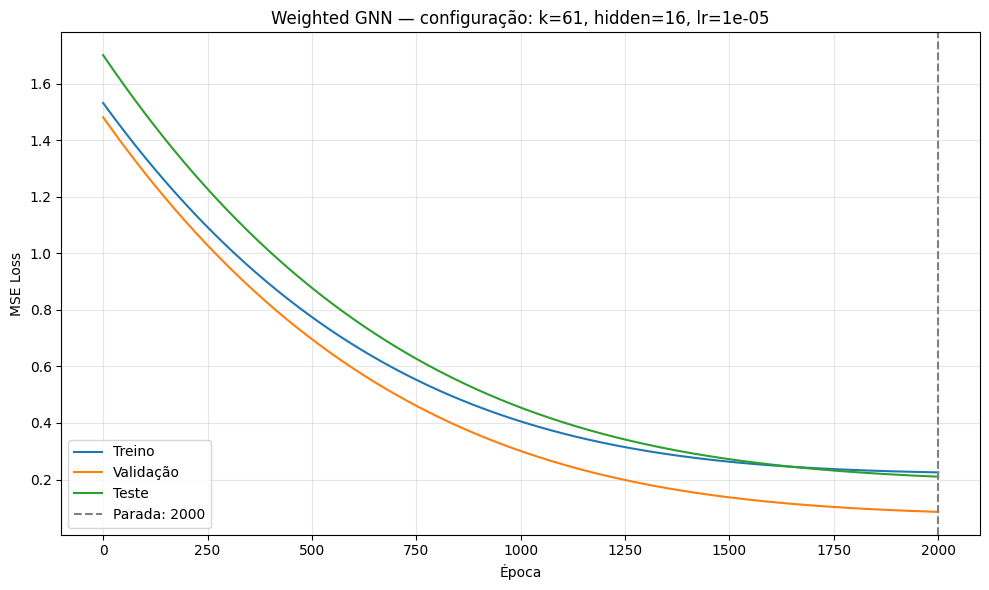

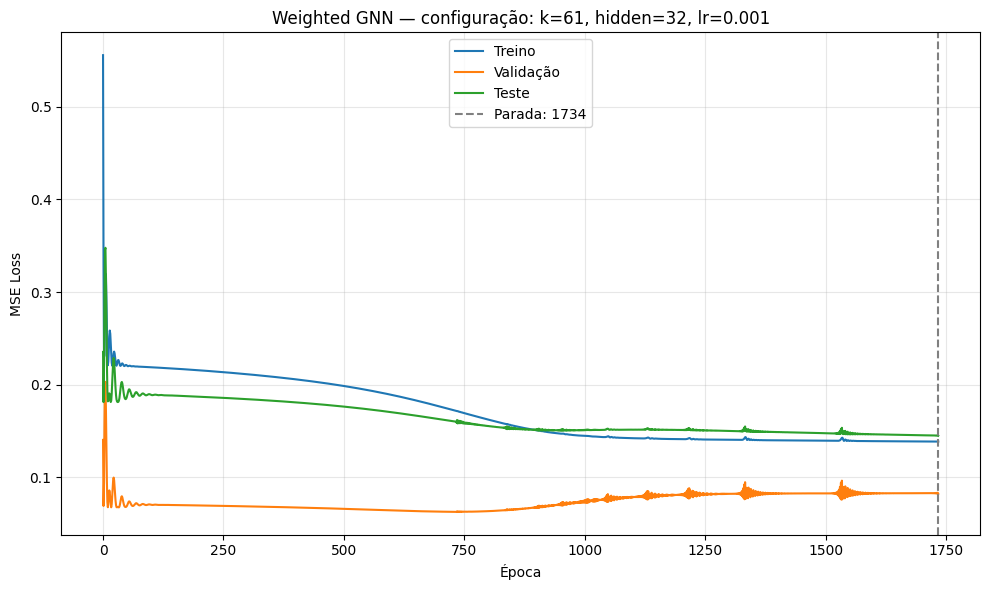

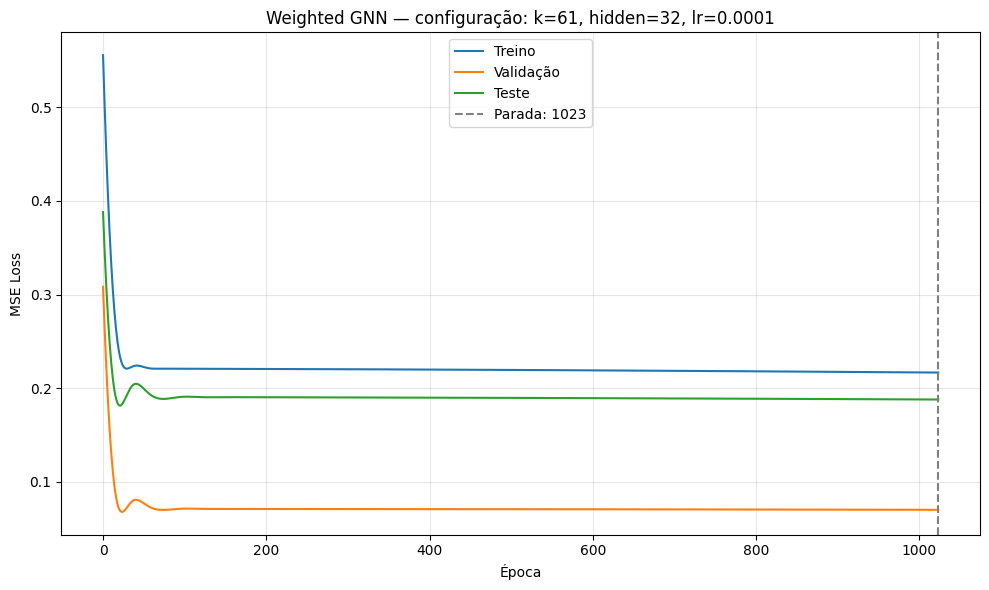

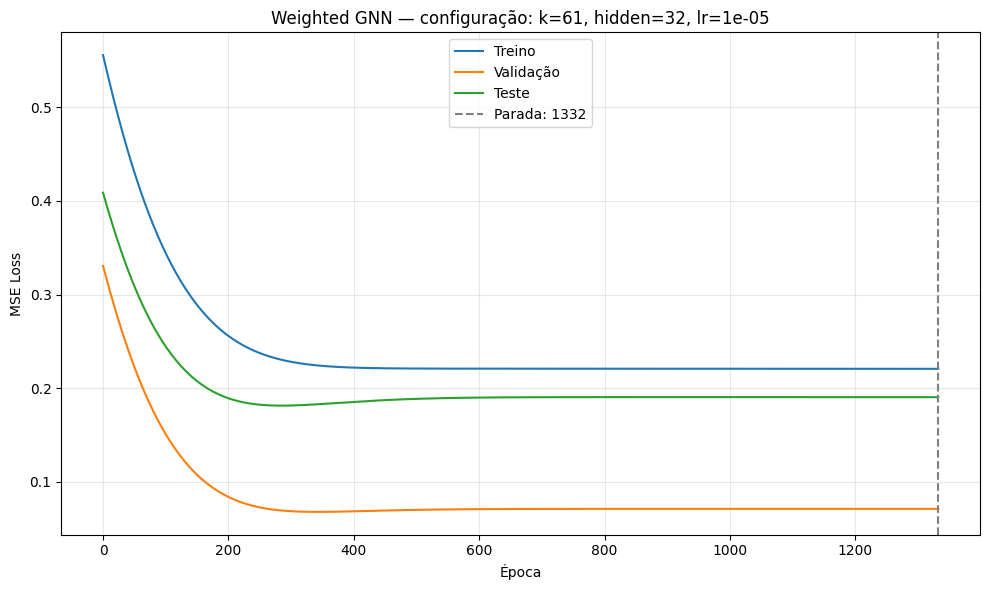

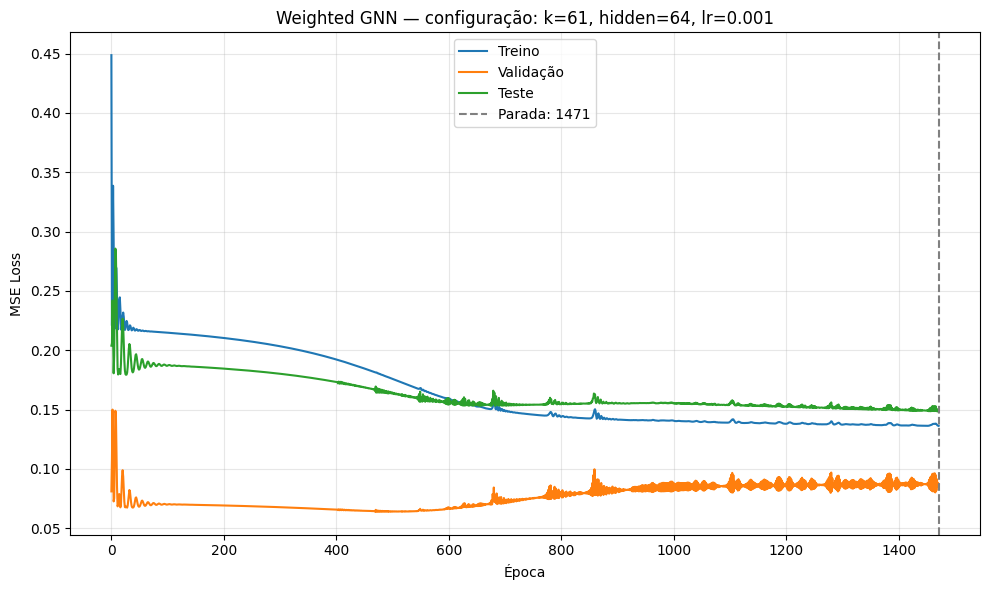

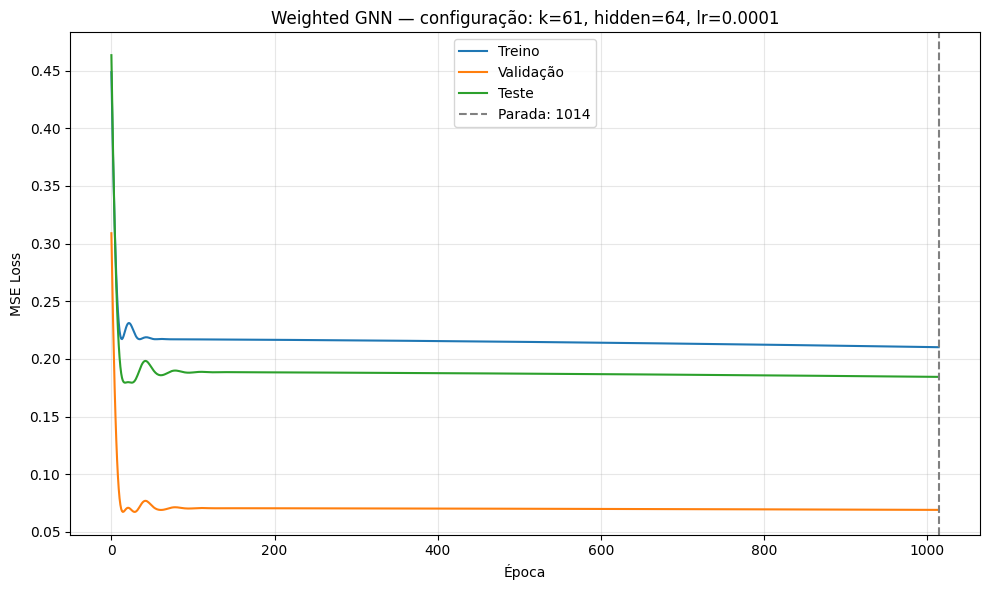

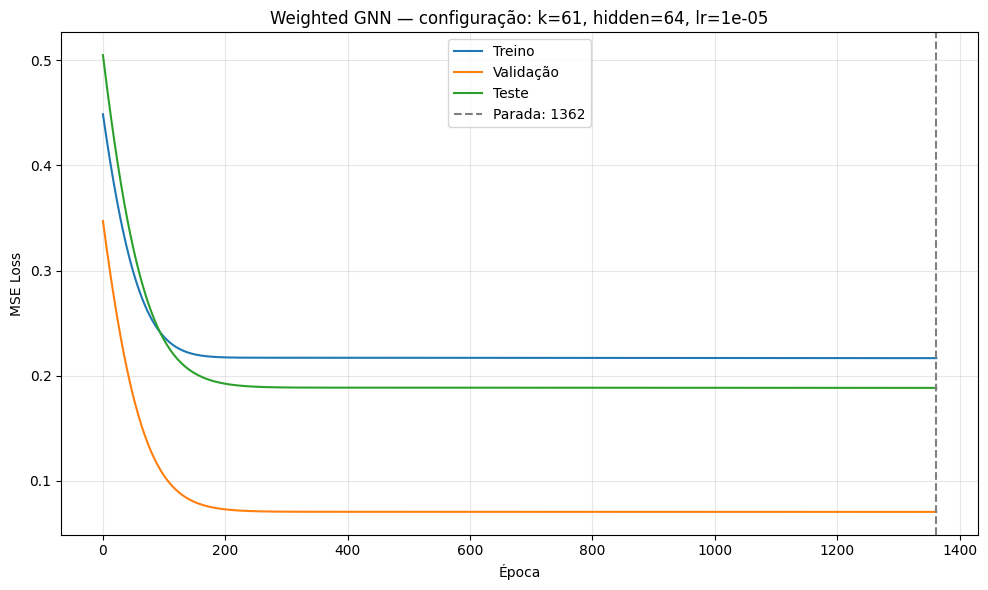

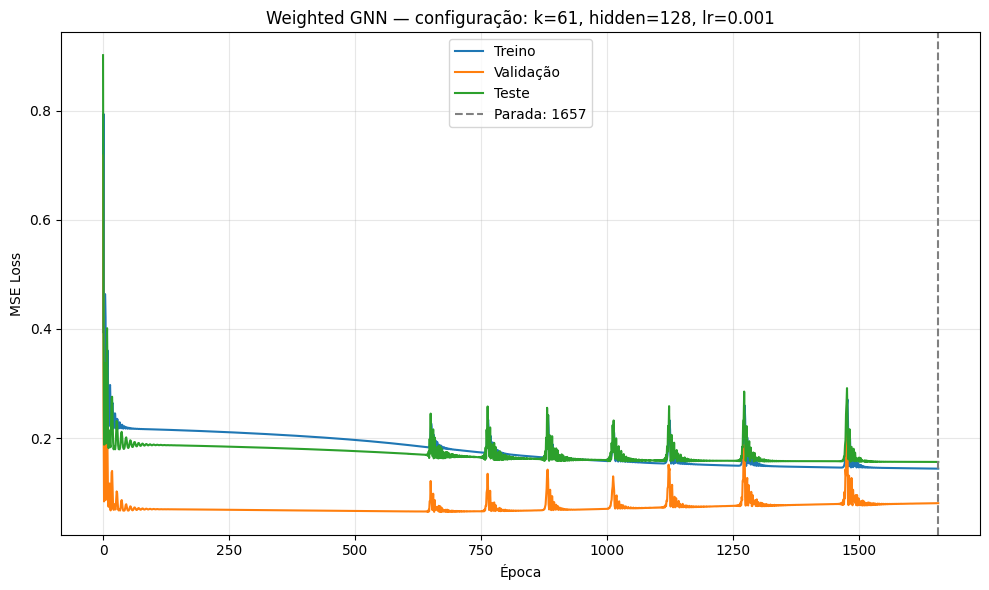

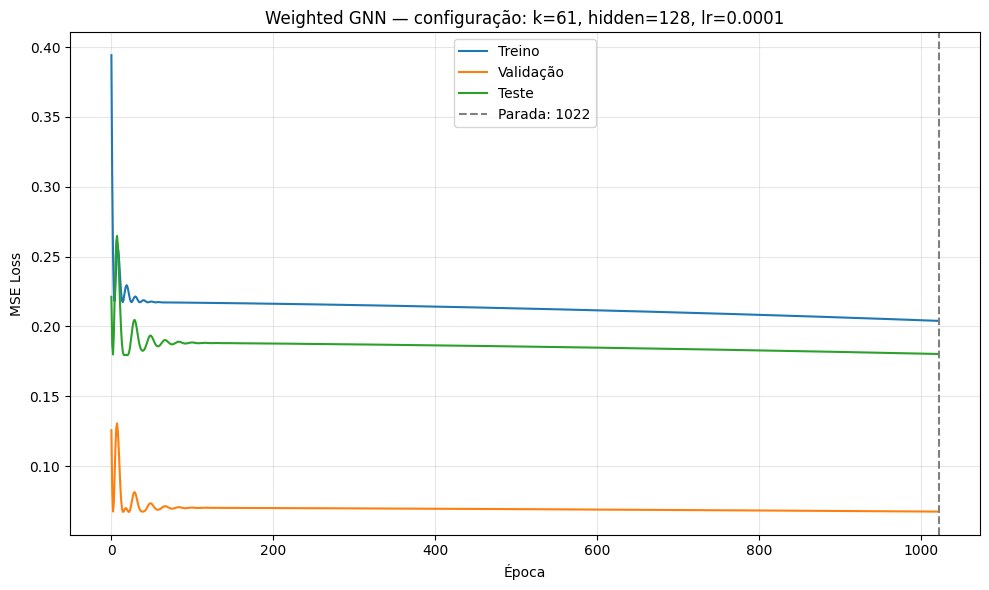

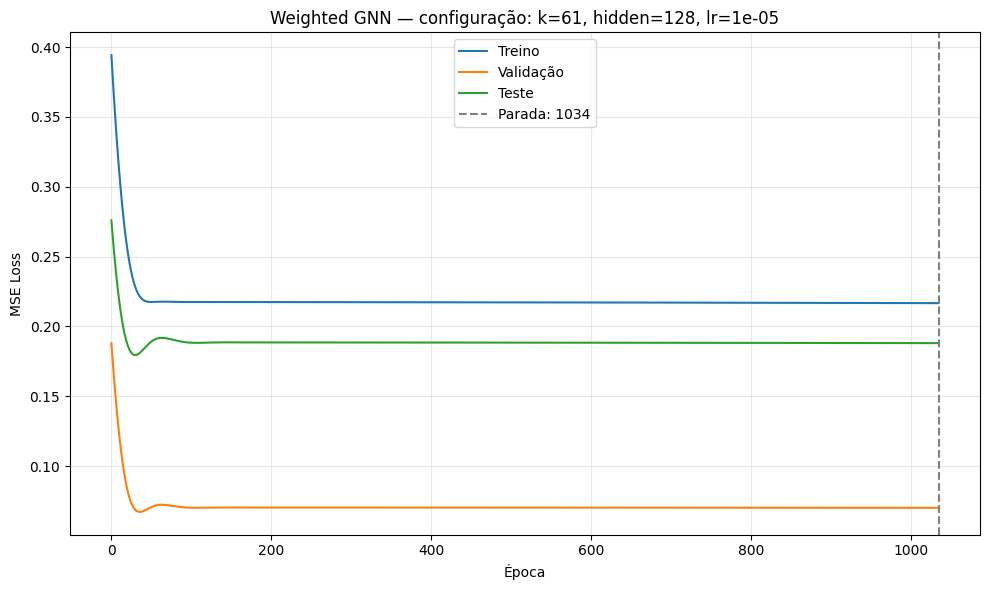

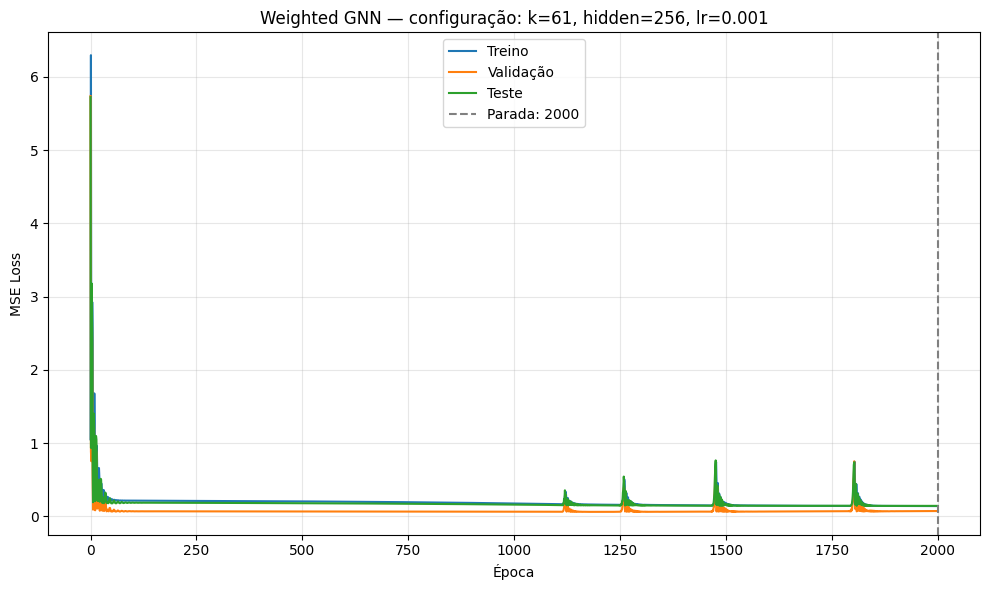

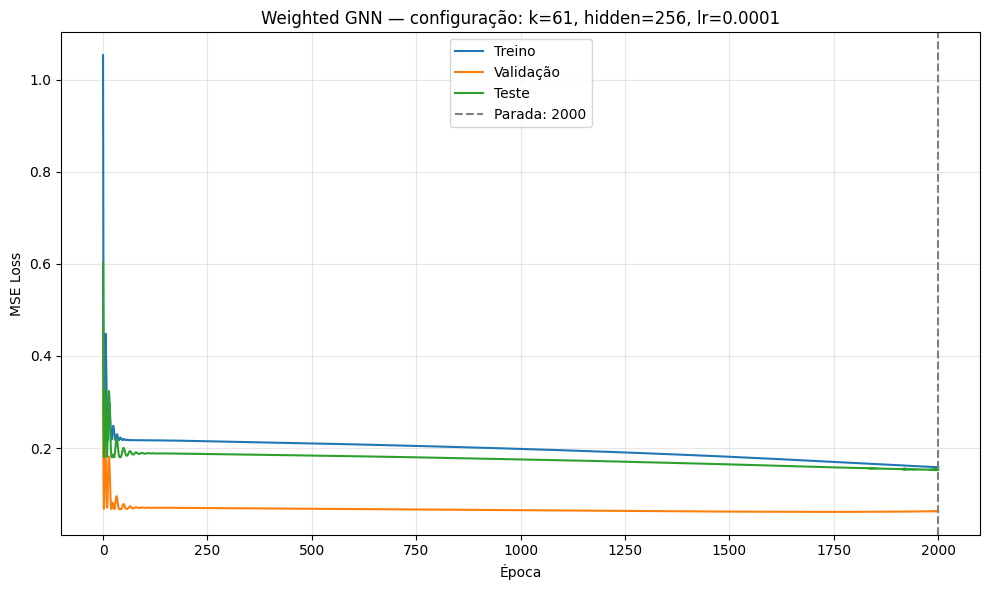

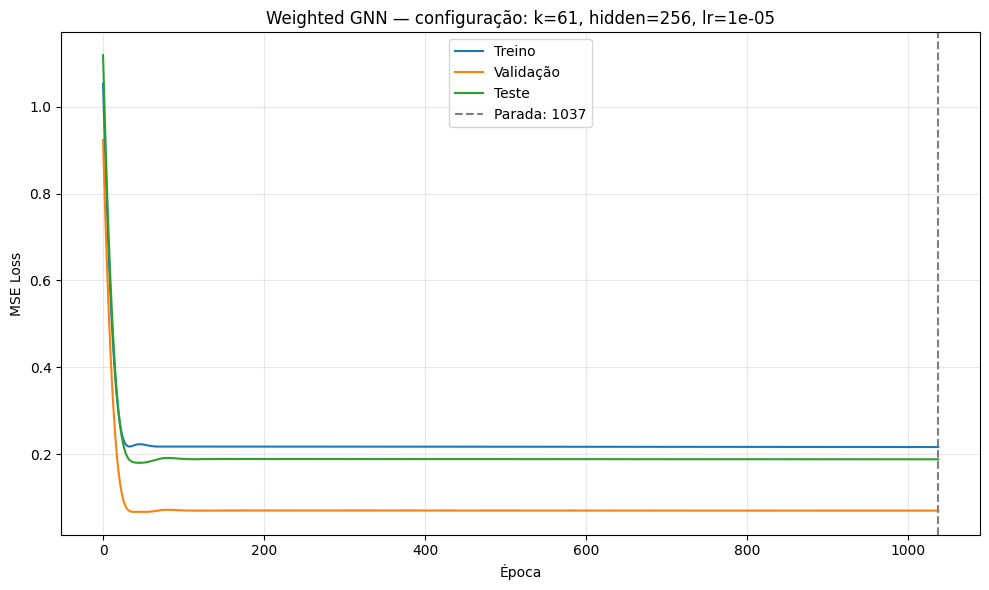

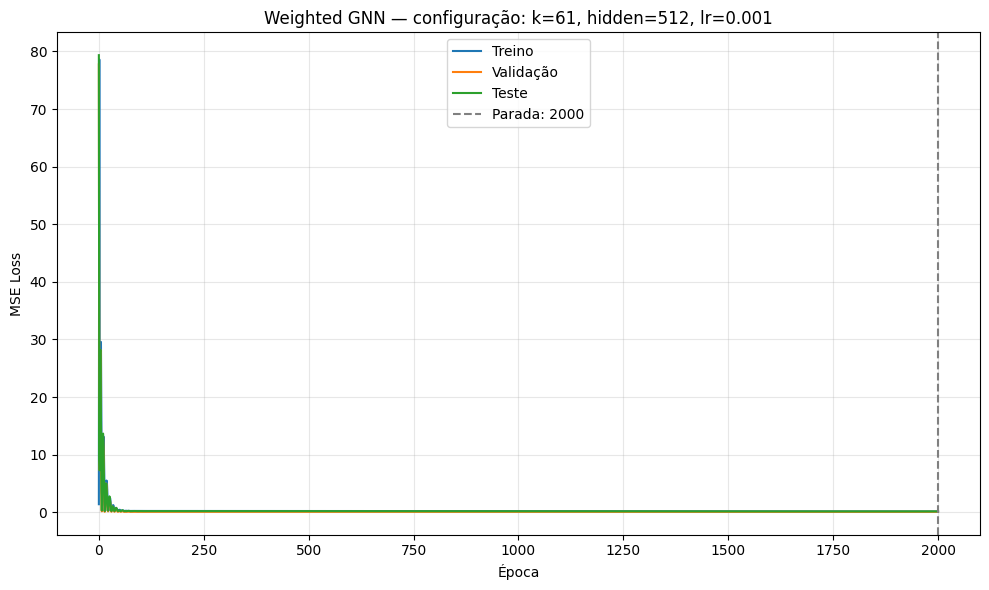

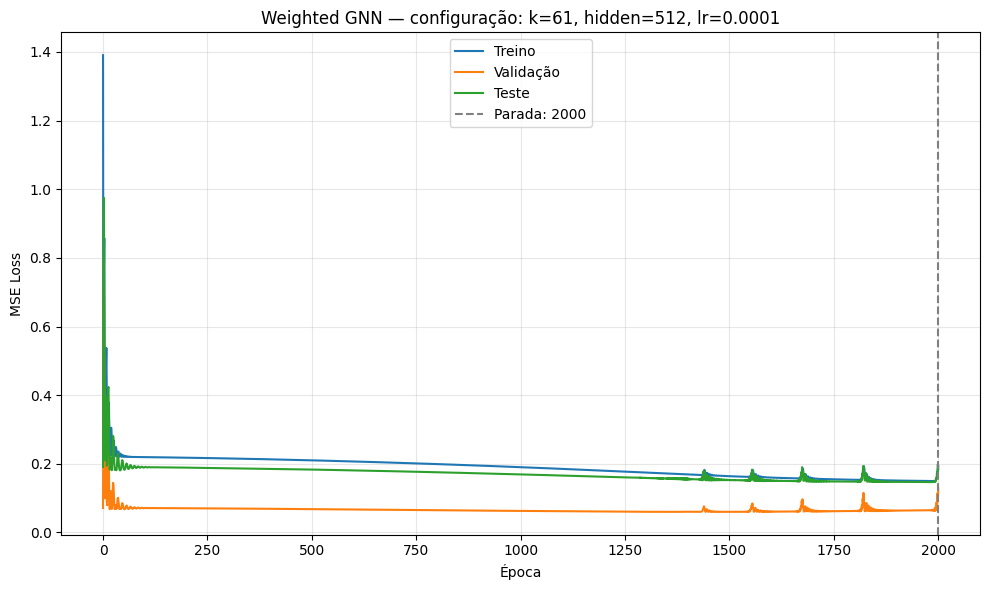

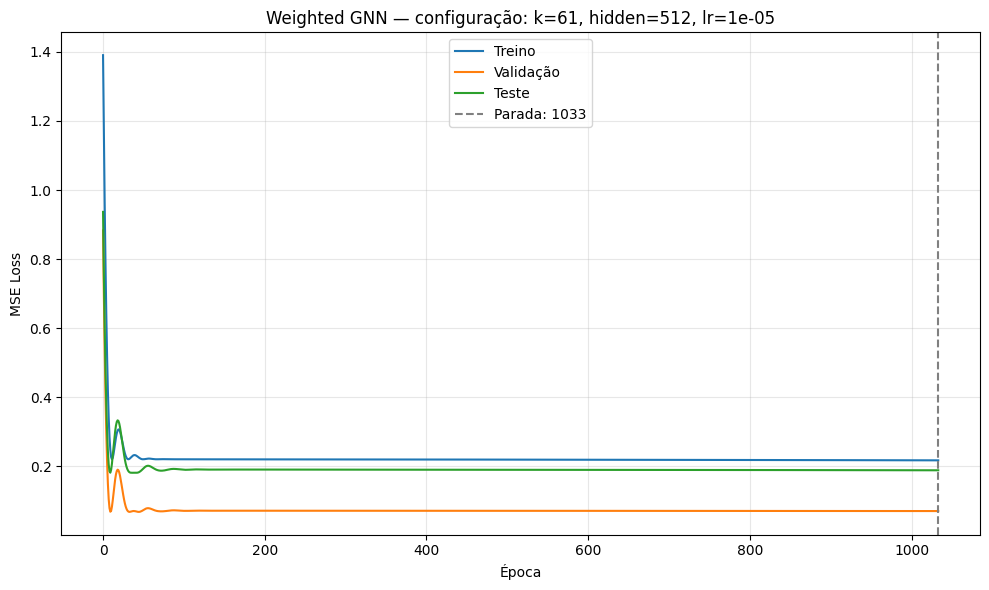

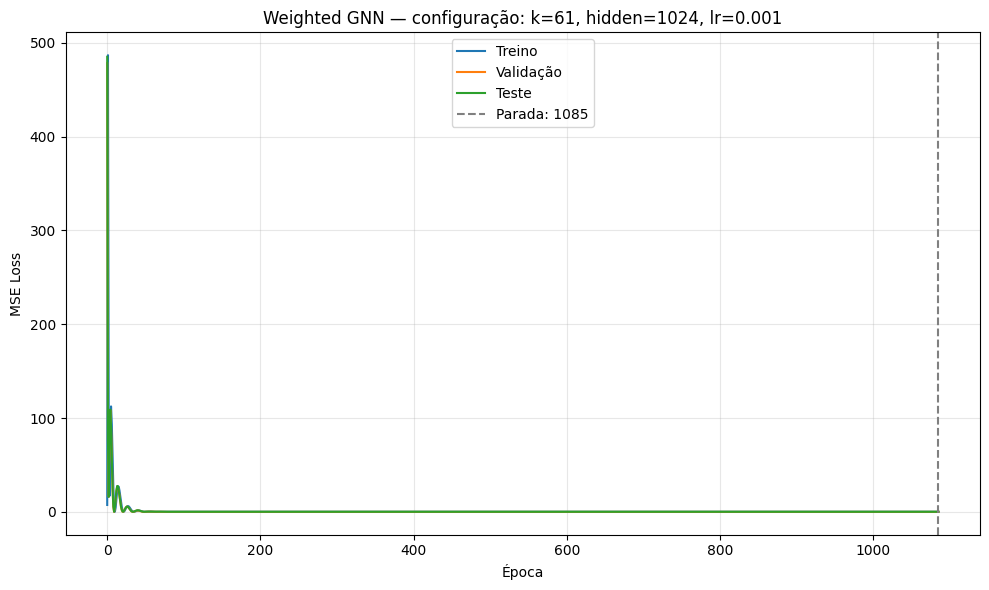

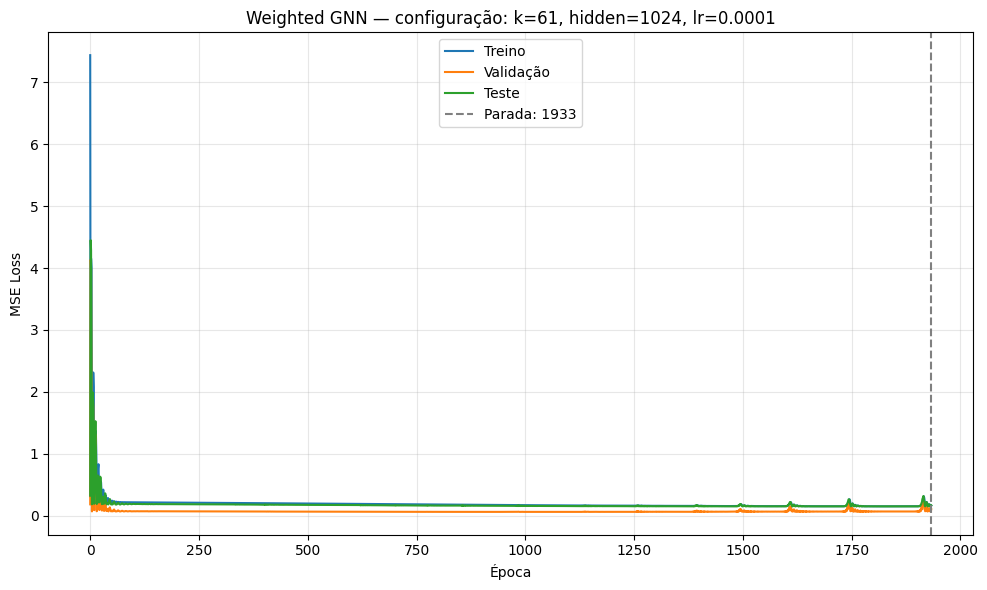

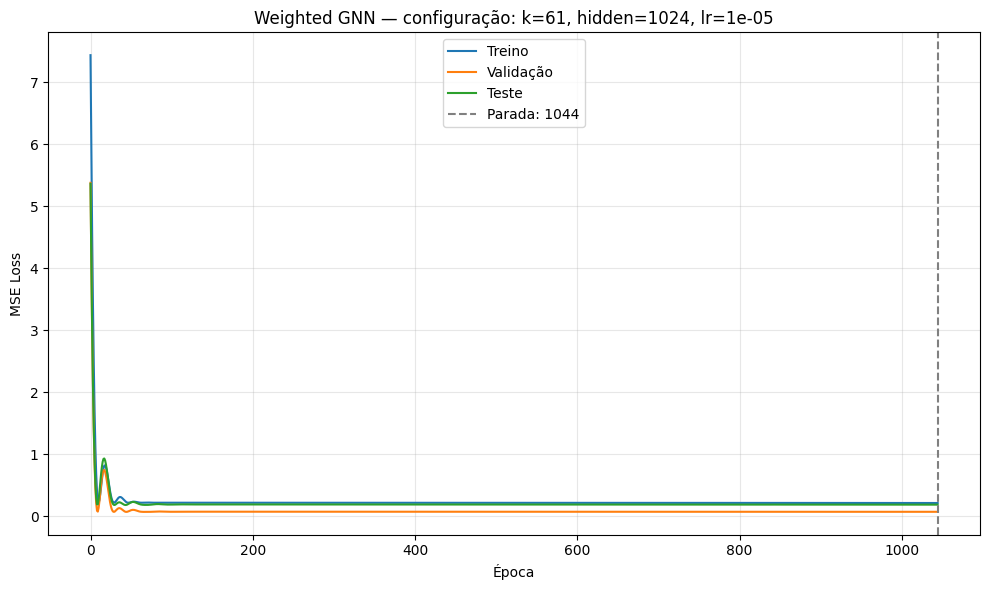

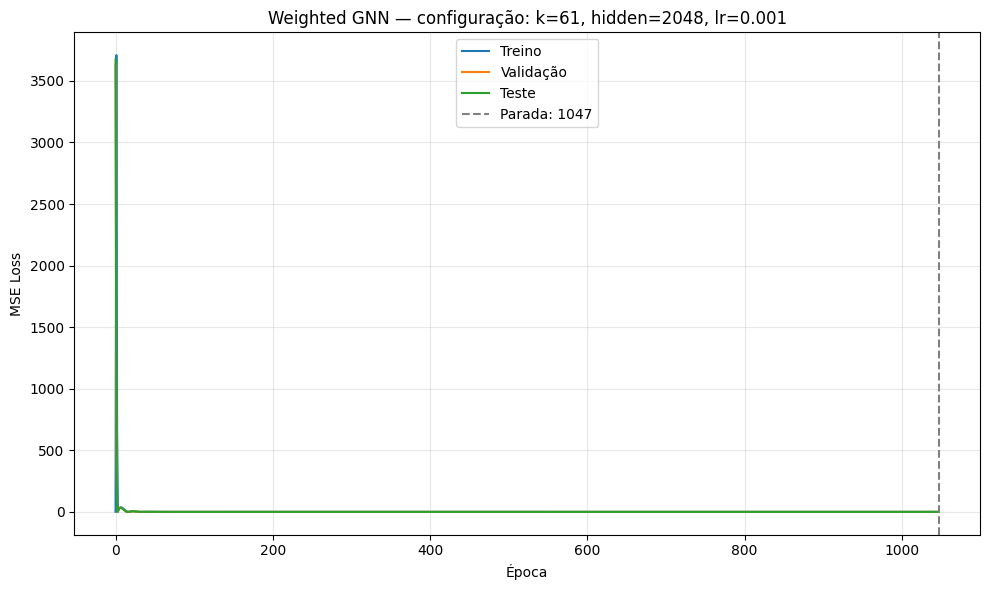

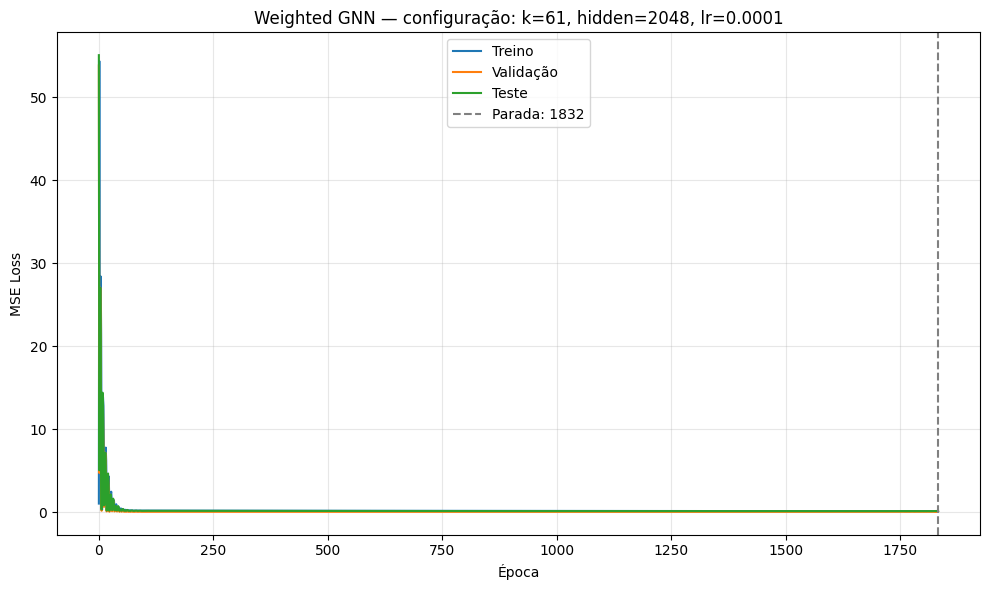

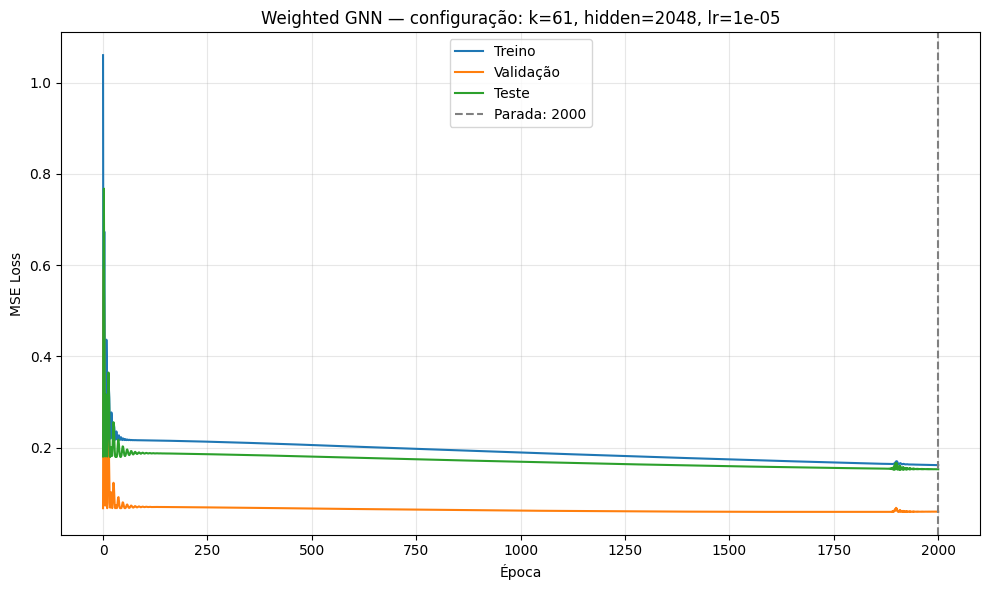

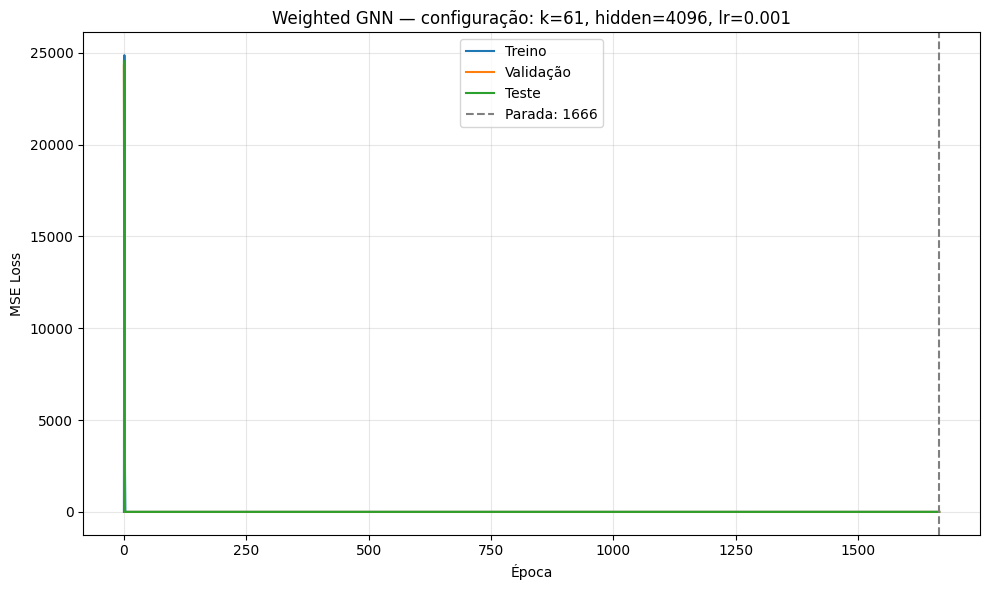

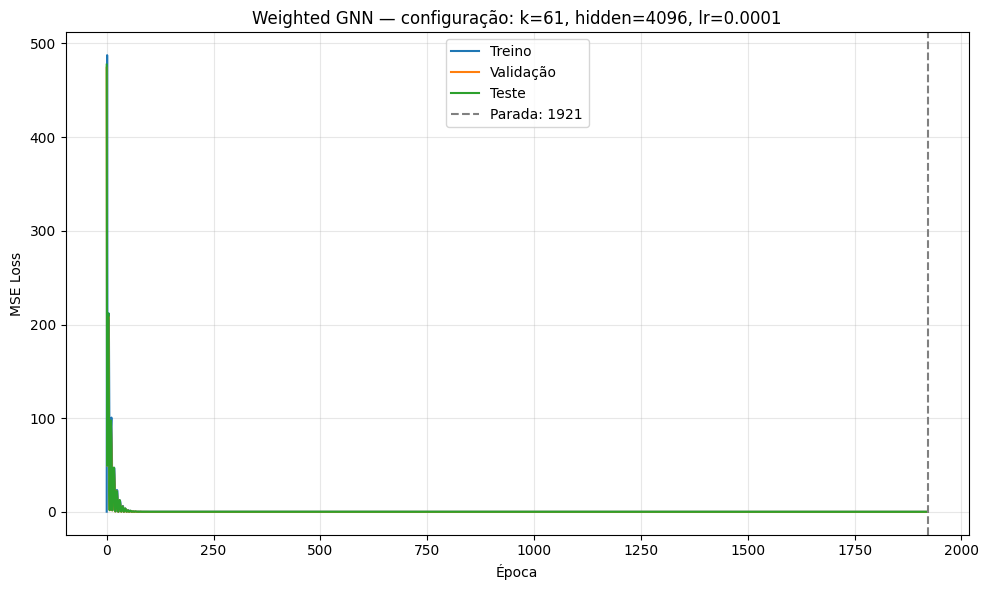

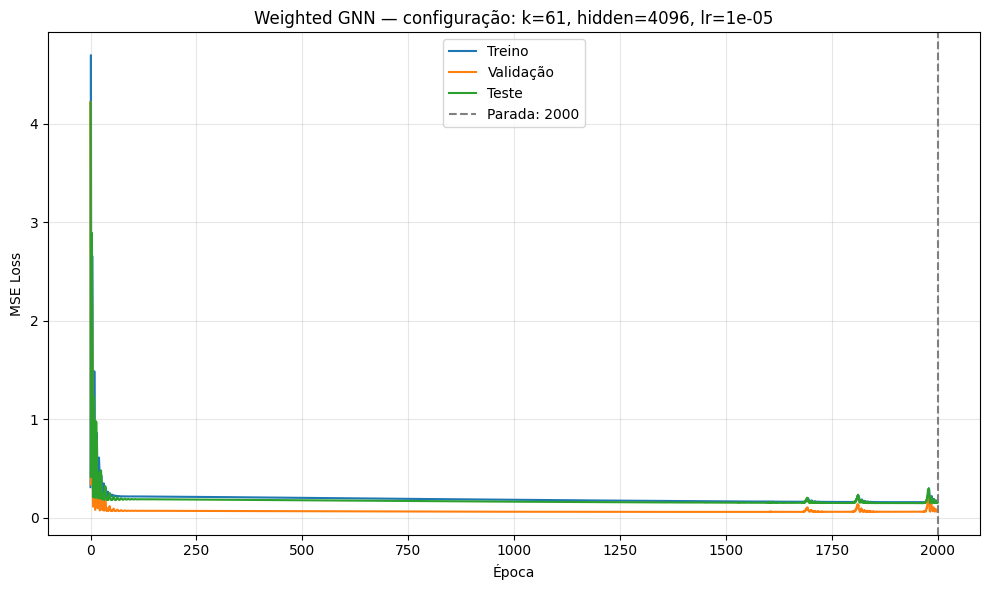

In [38]:
stop_epochs = {
    tuple(row[name] for name in grid_names): row["stop_epoch"]
    for row in grid_rows
}

for config_key, history_run in grid_histories.items():
    config = dict(zip(grid_names, config_key))
    stop_epoch = stop_epochs[config_key]
    epochs_executed = range(len(history_run["train"]))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs_executed, history_run["train"], label="Treino")
    ax.plot(epochs_executed, history_run["validation"], label="Validação")
    ax.plot(epochs_executed, history_run["test"], label="Teste")
    ax.axvline(
        stop_epoch,
        color="gray",
        linestyle="--",
        label=f"Parada: {stop_epoch}",
    )

    ax.set(
        title=(
            "Weighted GNN — configuração: "
            f"k={config['k']}, hidden={config['hidden_dim']}, "
            f"lr={config['learning_rate']}"
        ),
        xlabel="Época",
        ylabel="MSE Loss",
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

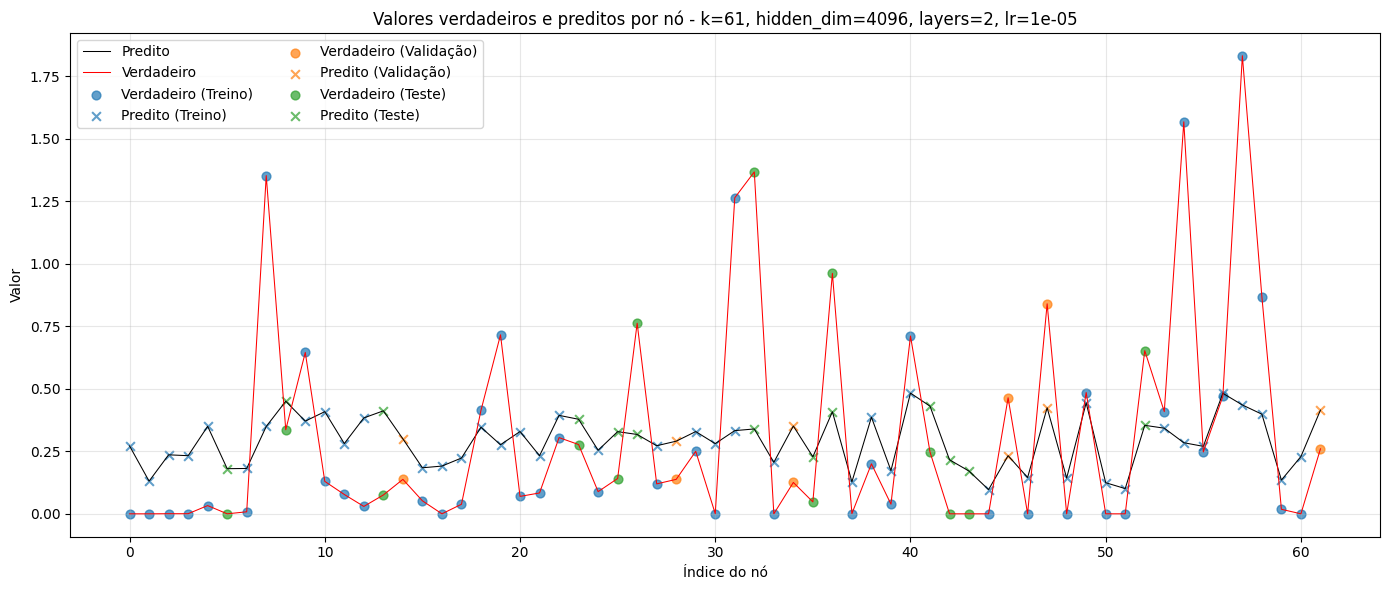

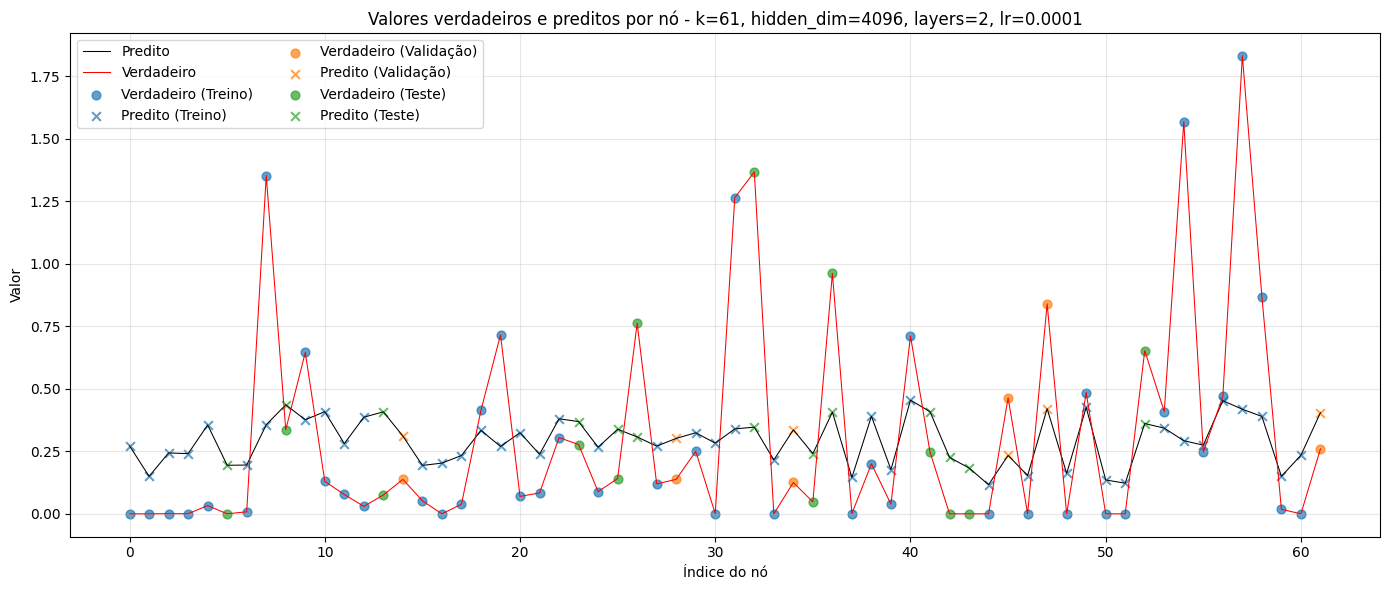

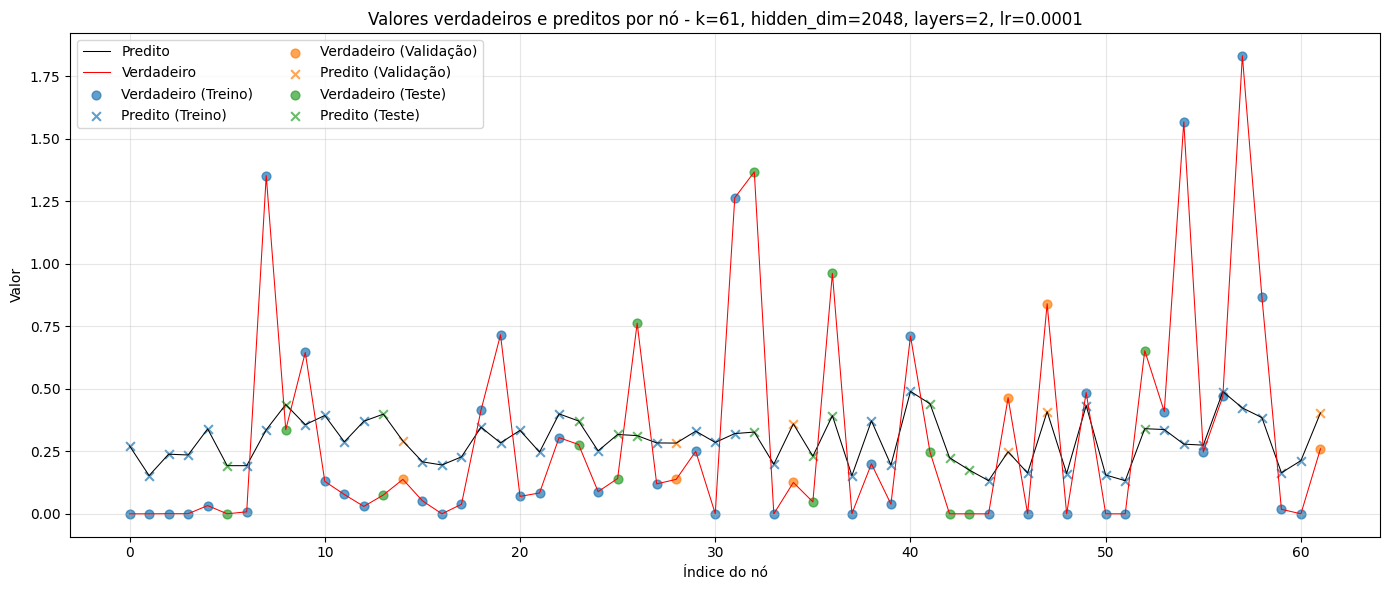

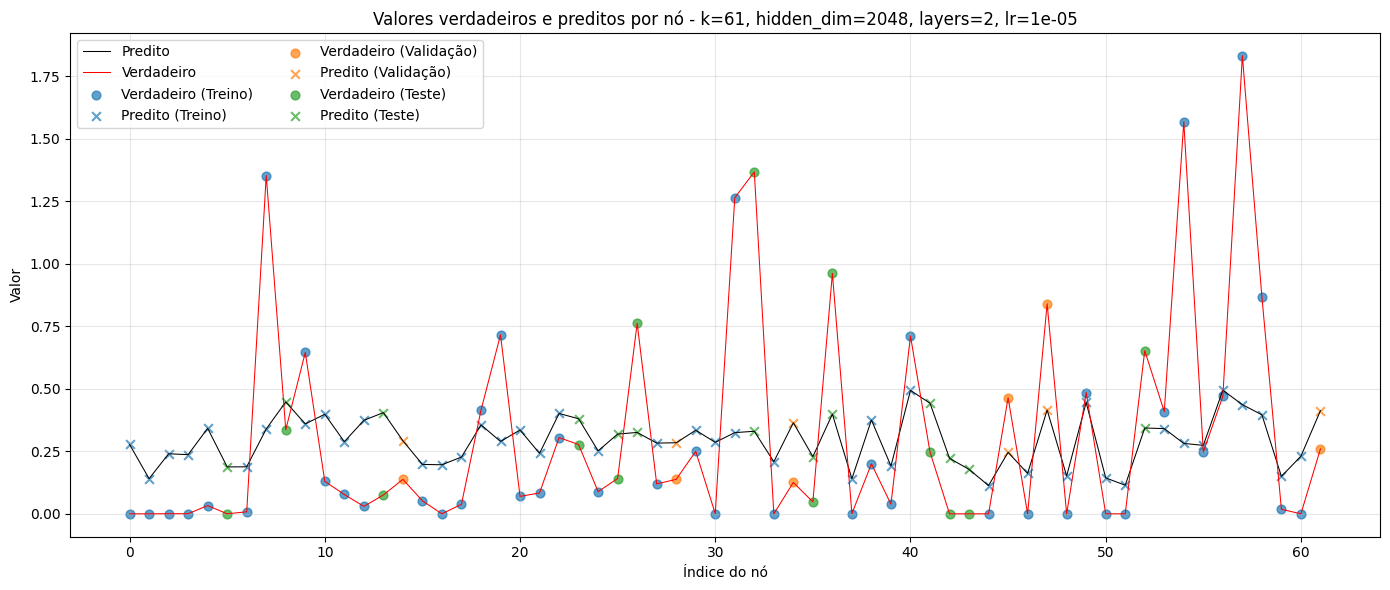

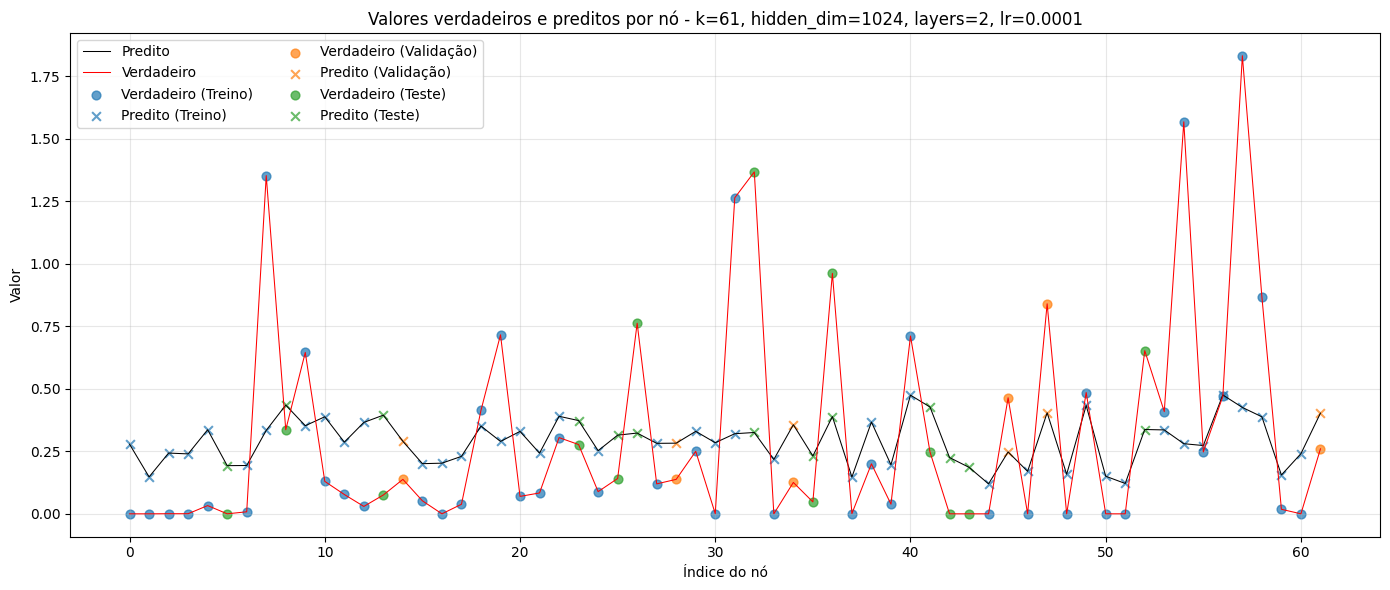

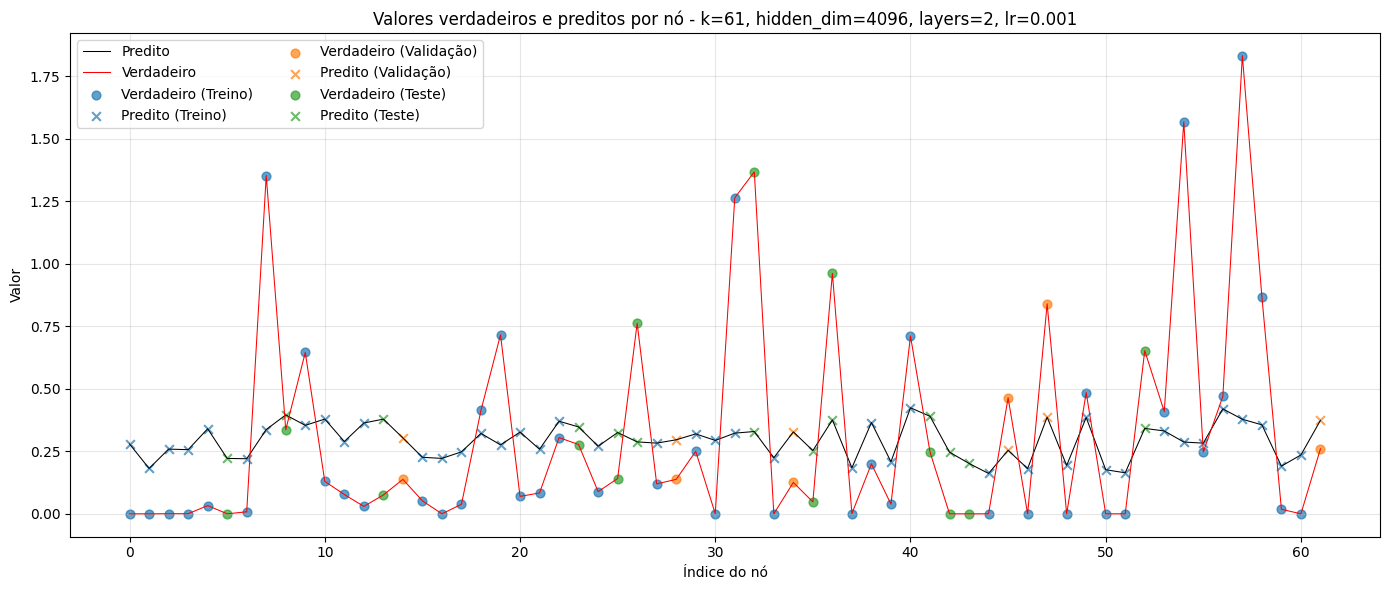

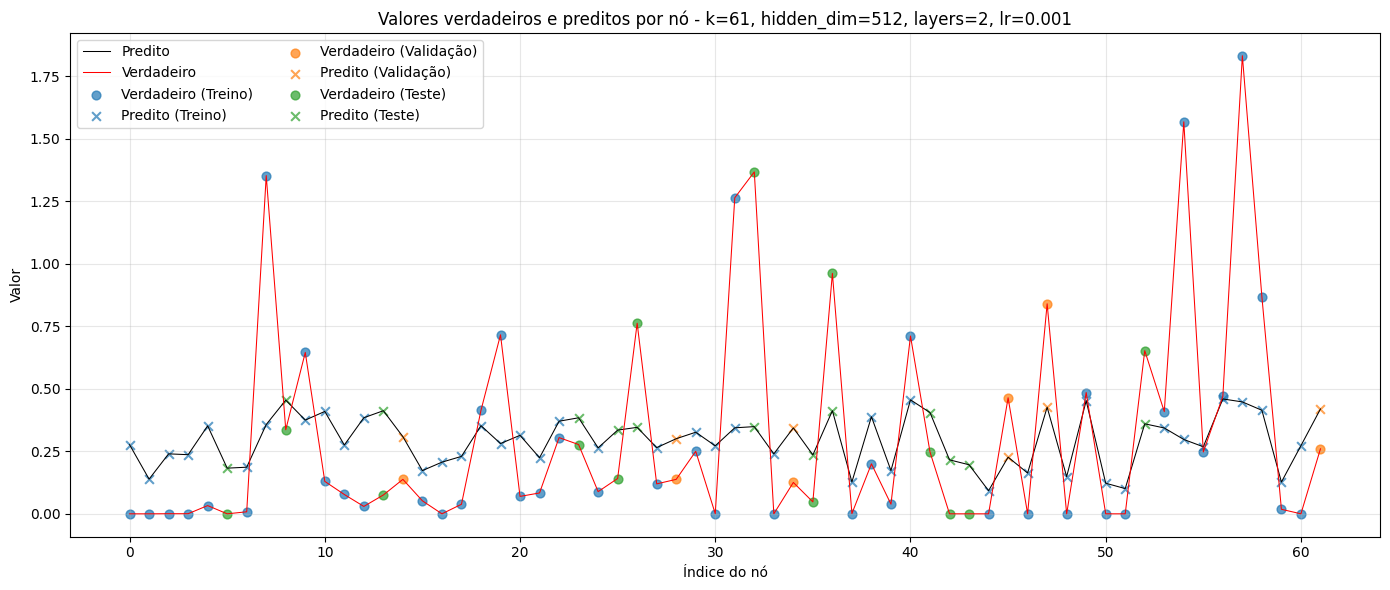

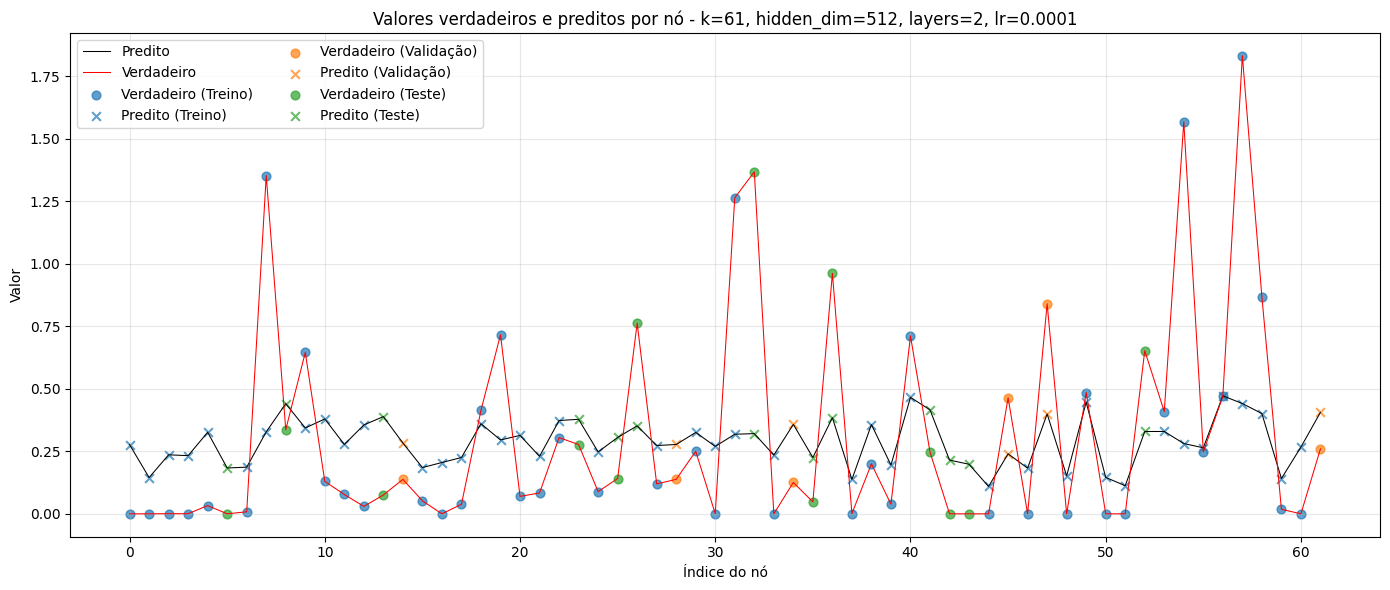

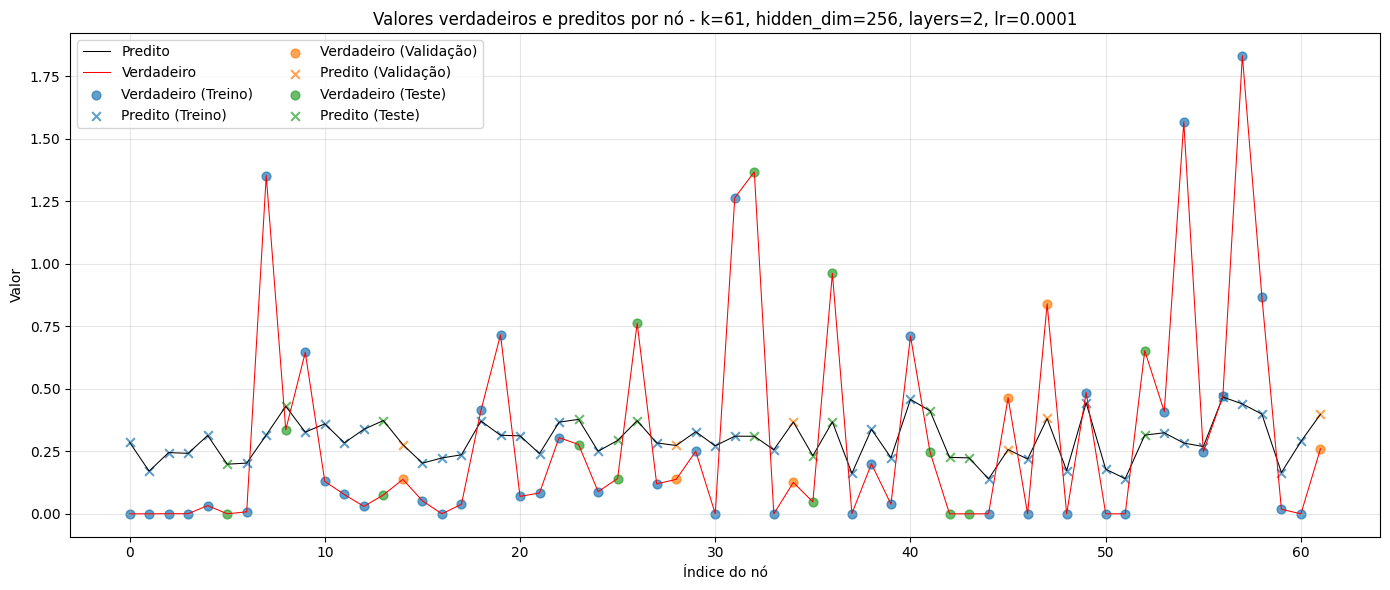

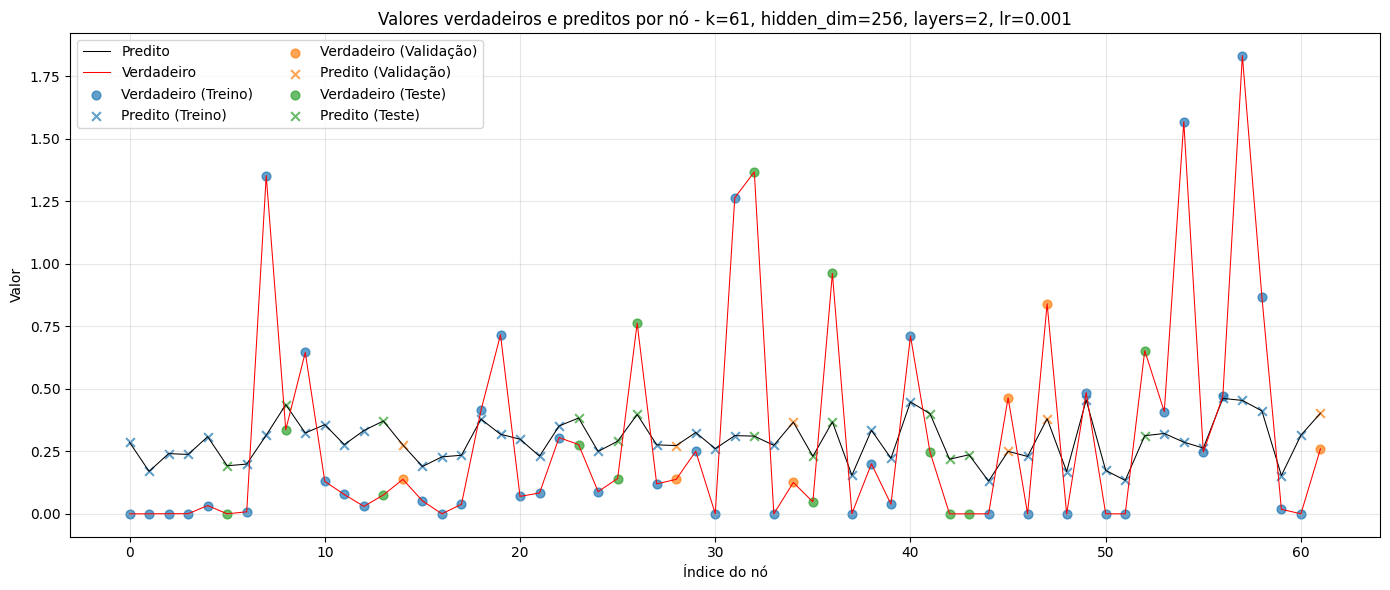

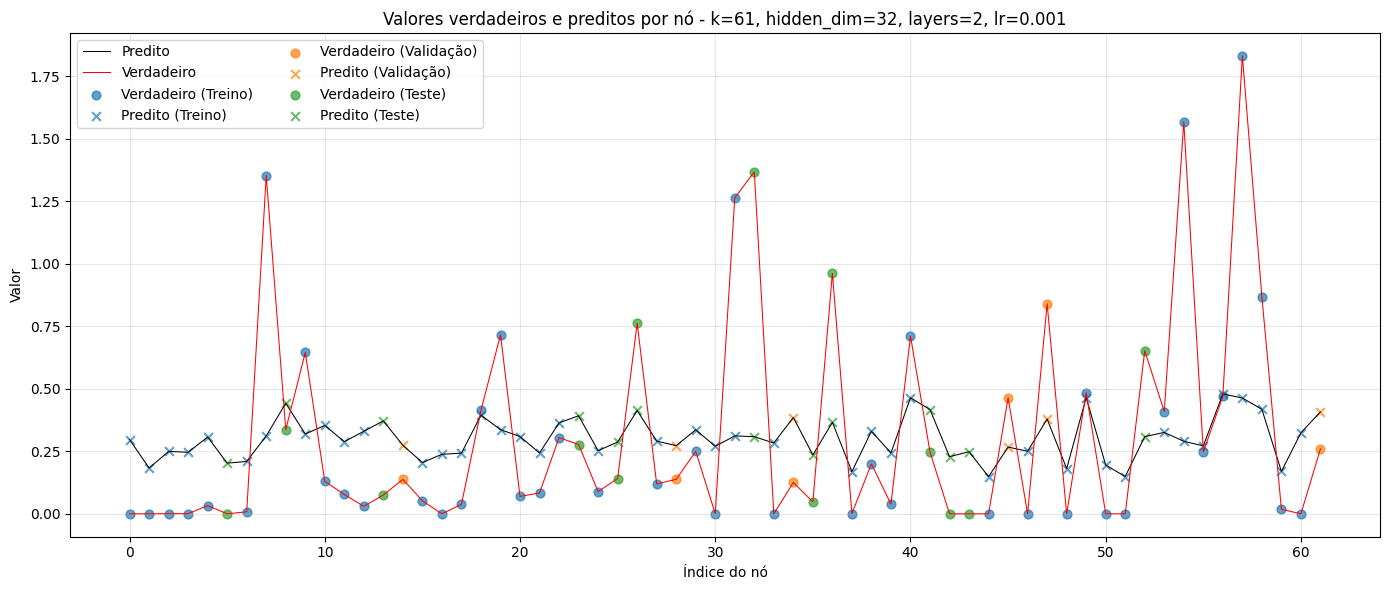

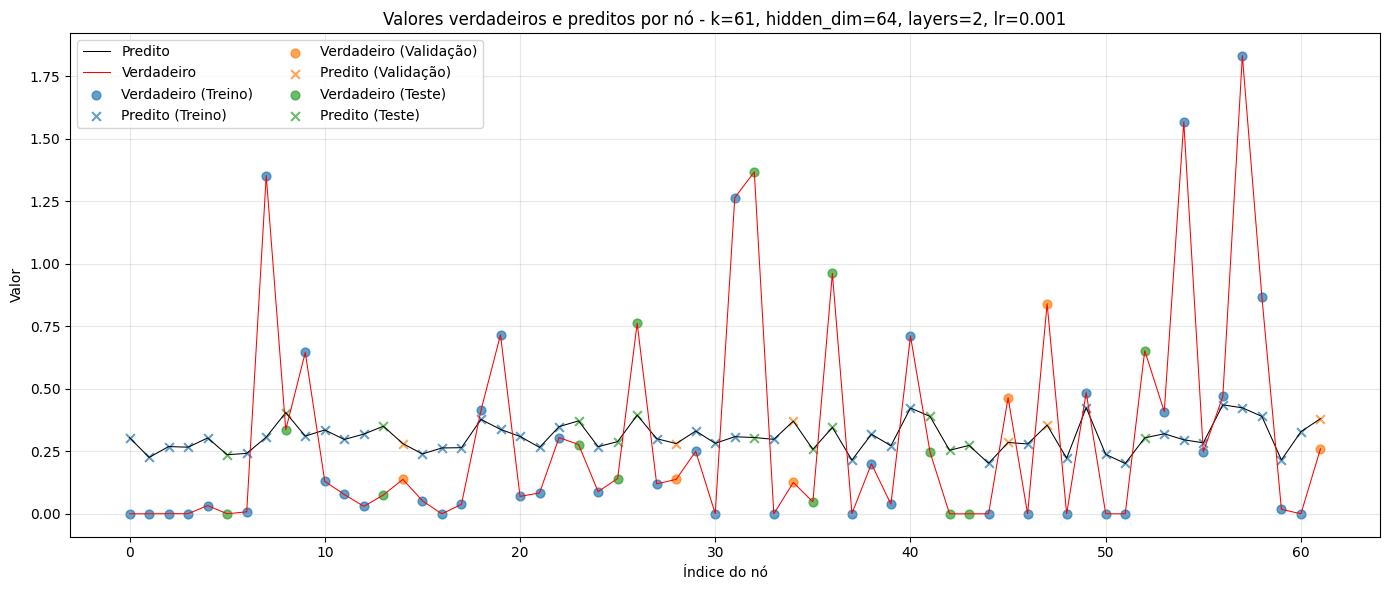

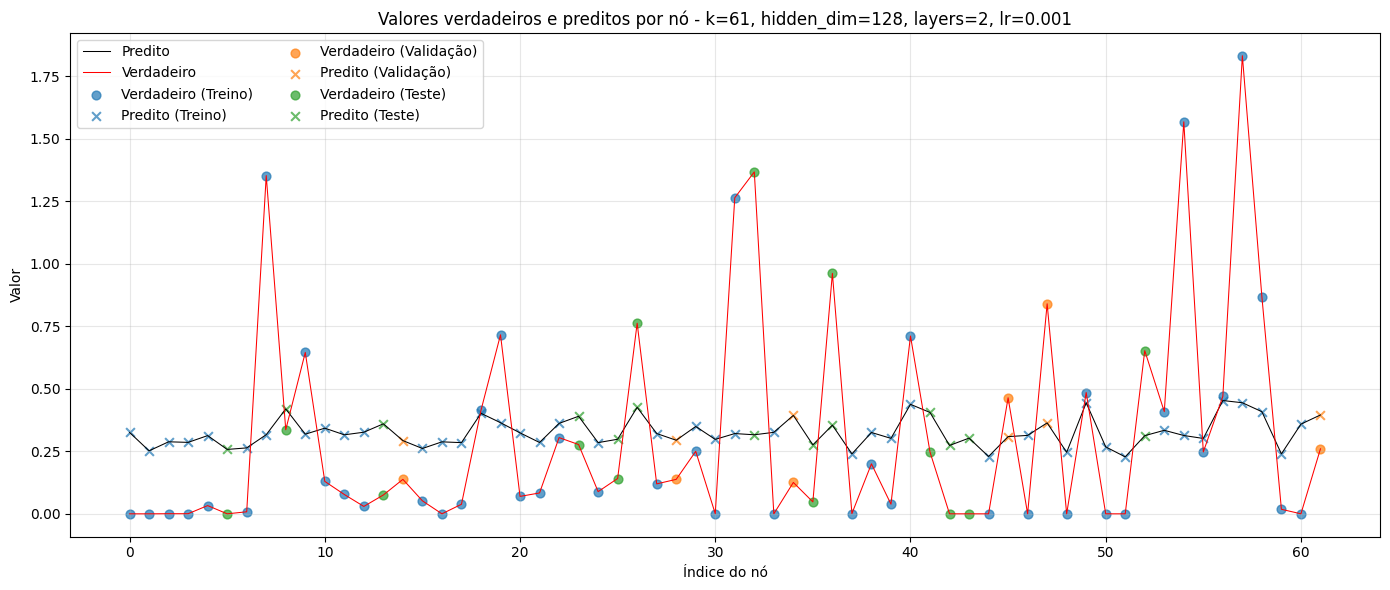

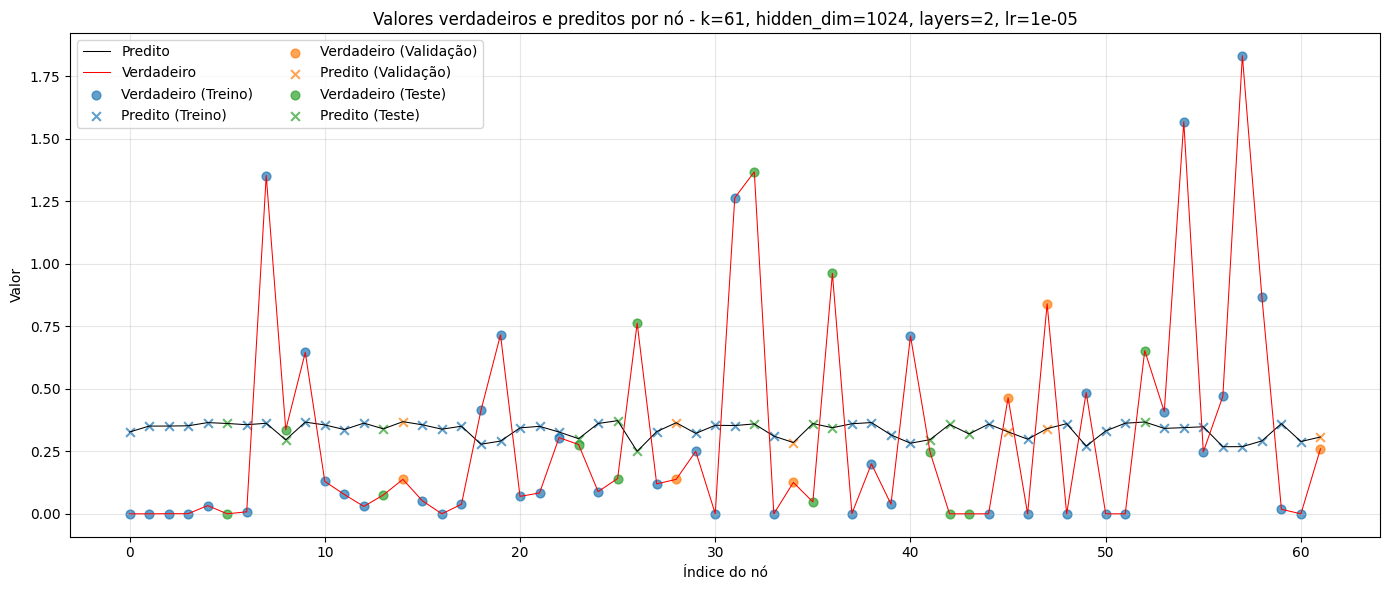

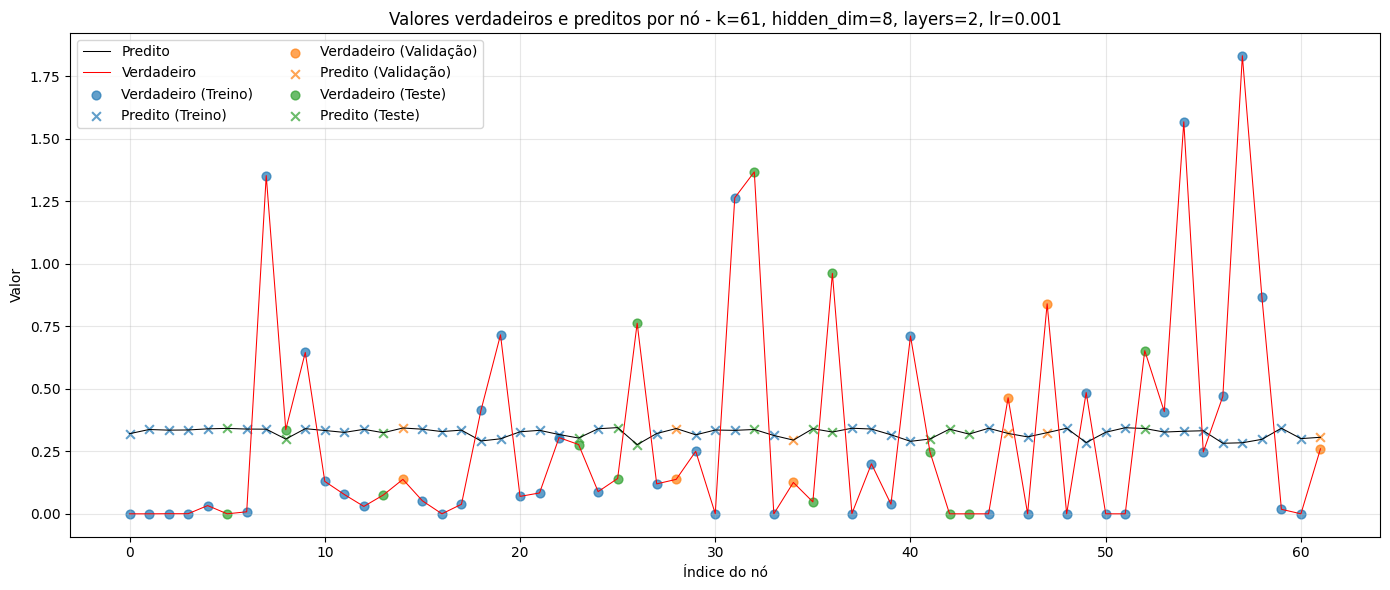

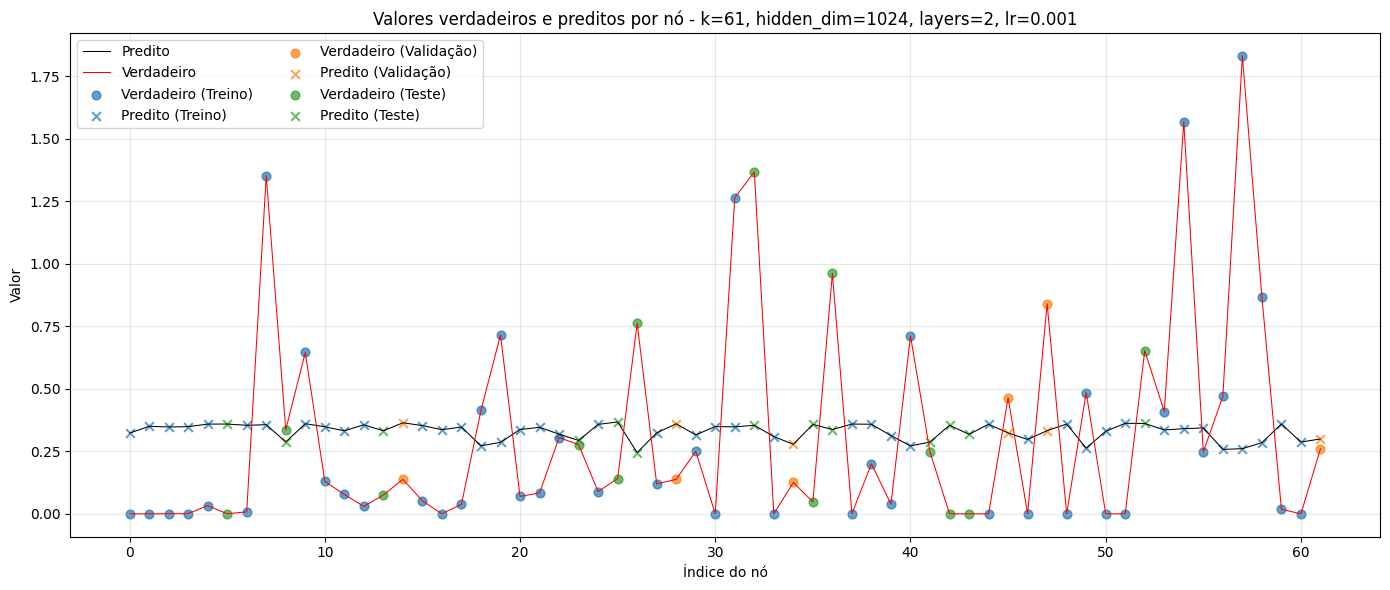

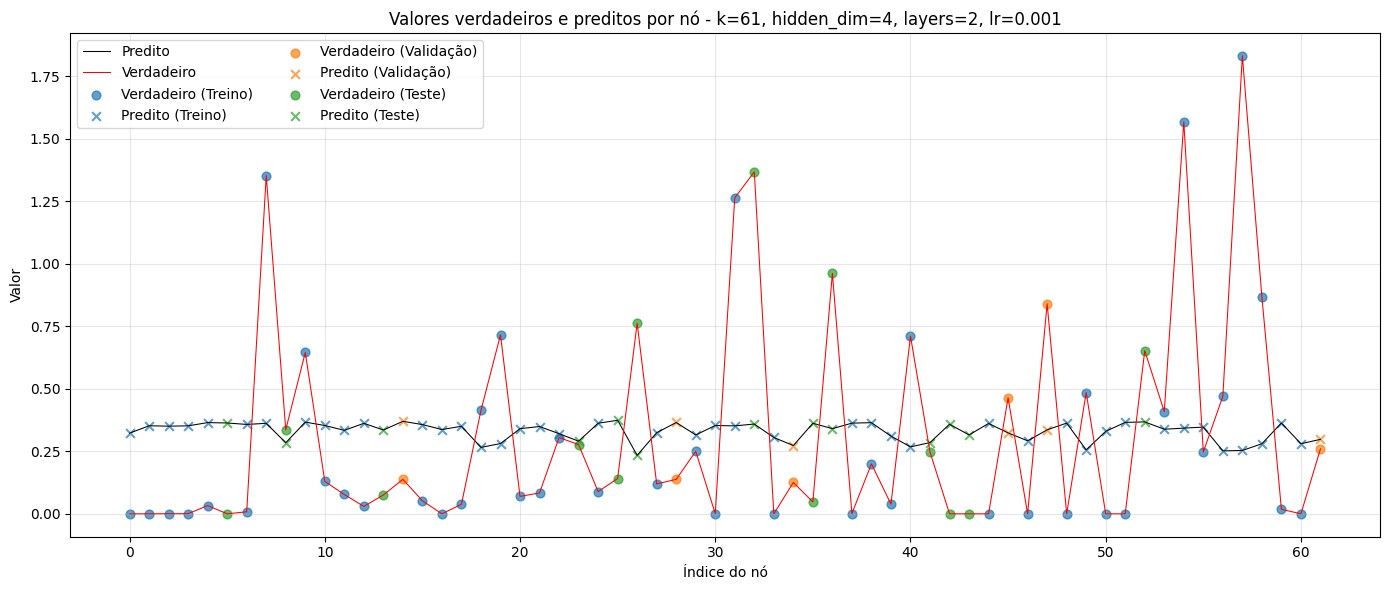

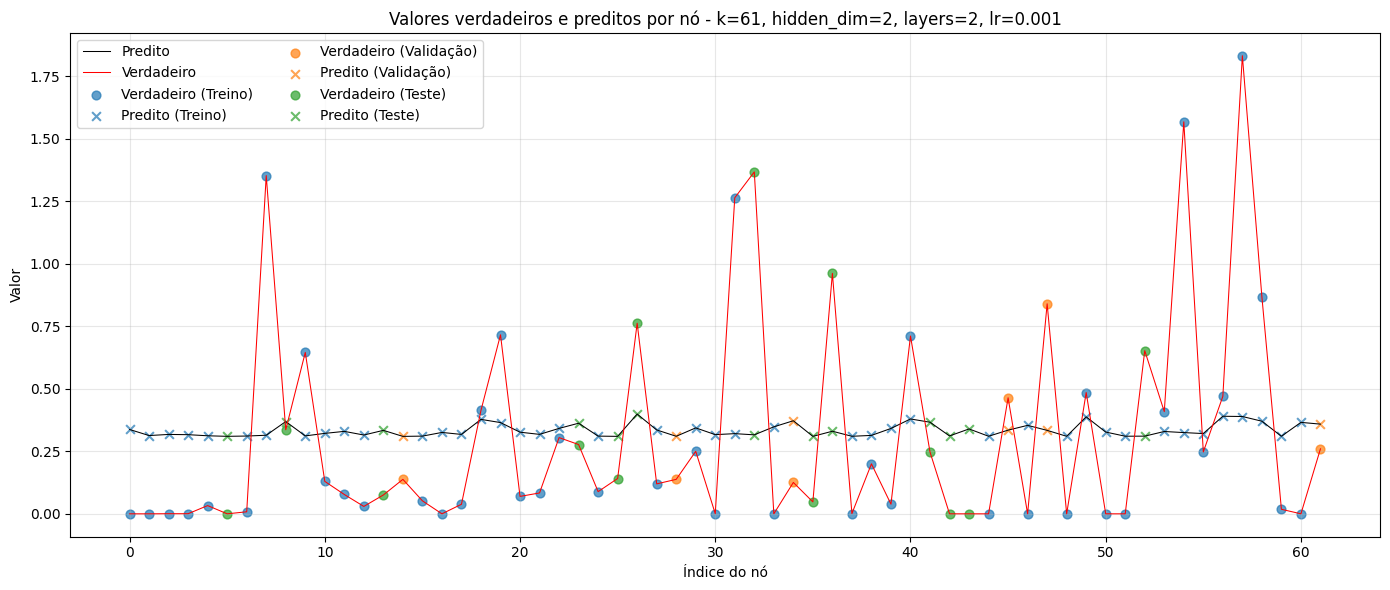

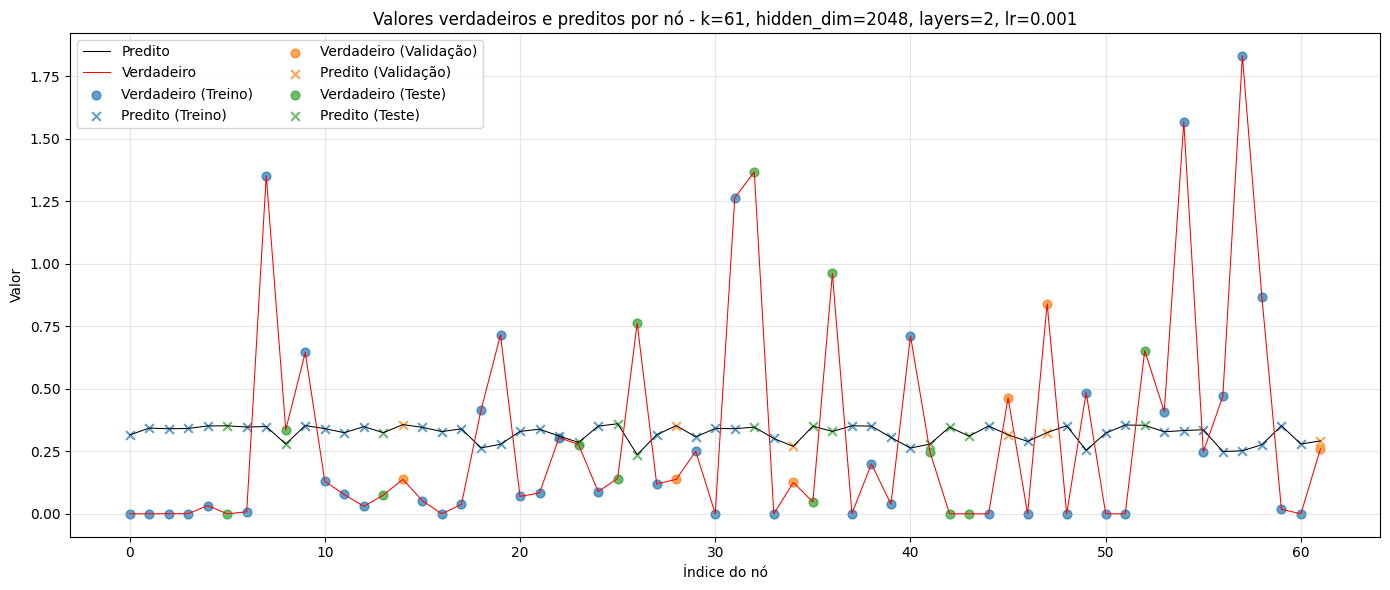

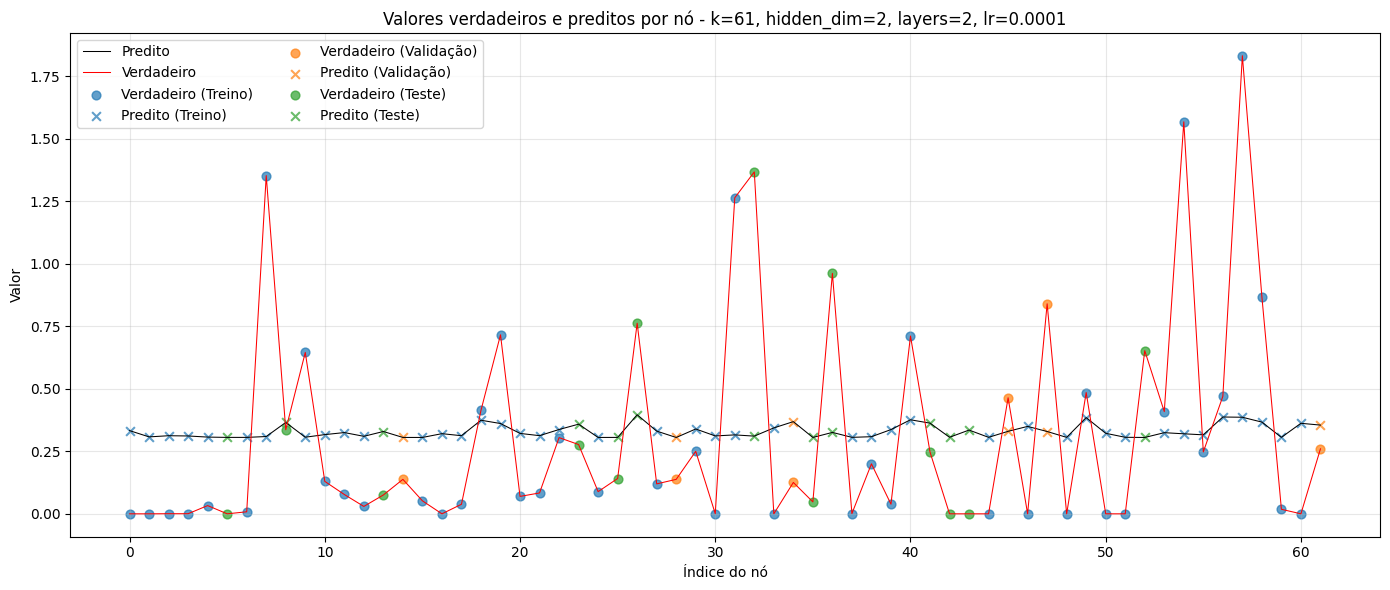

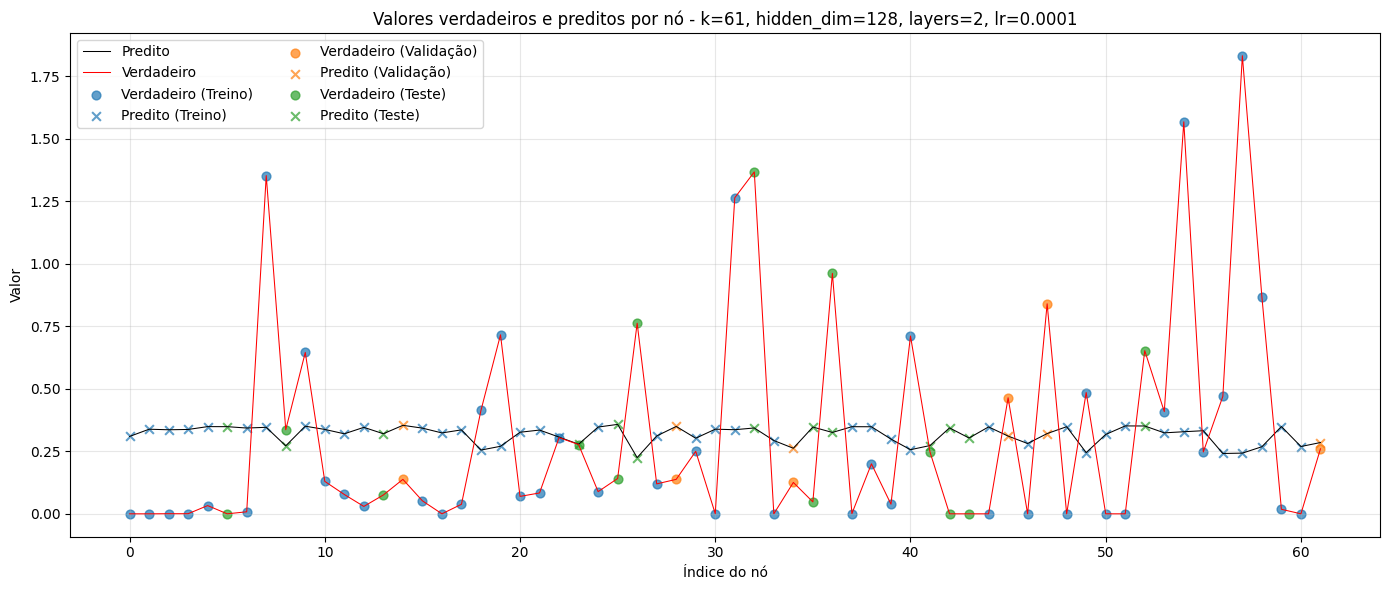

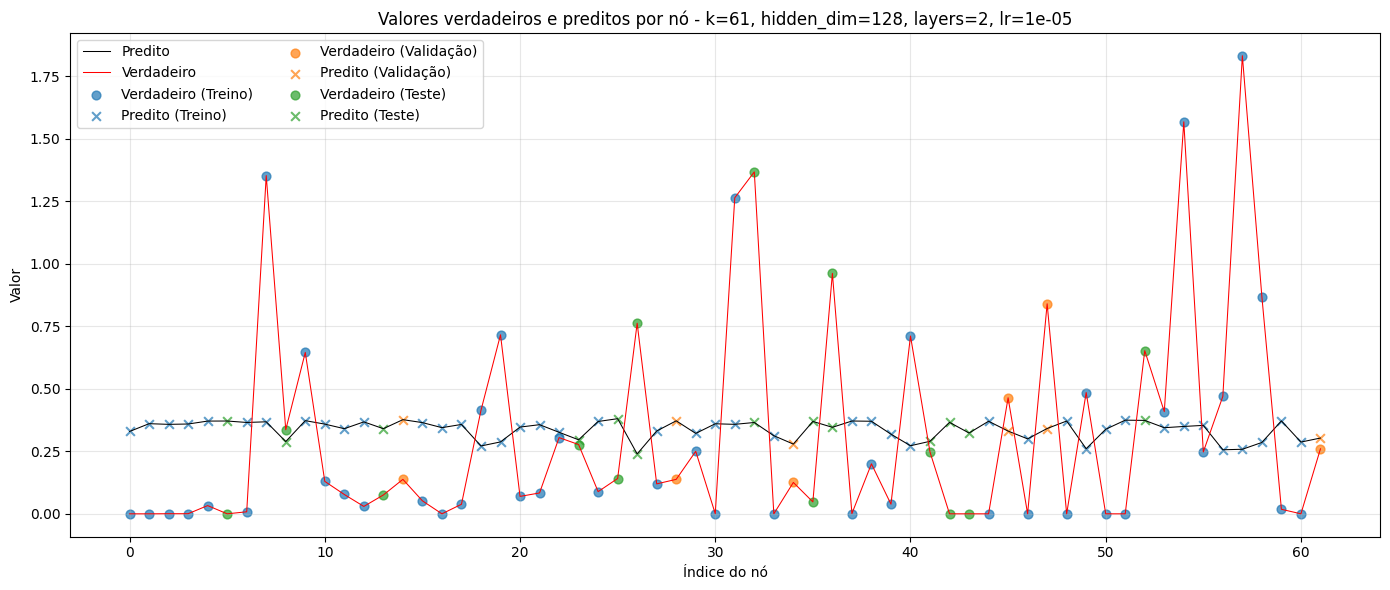

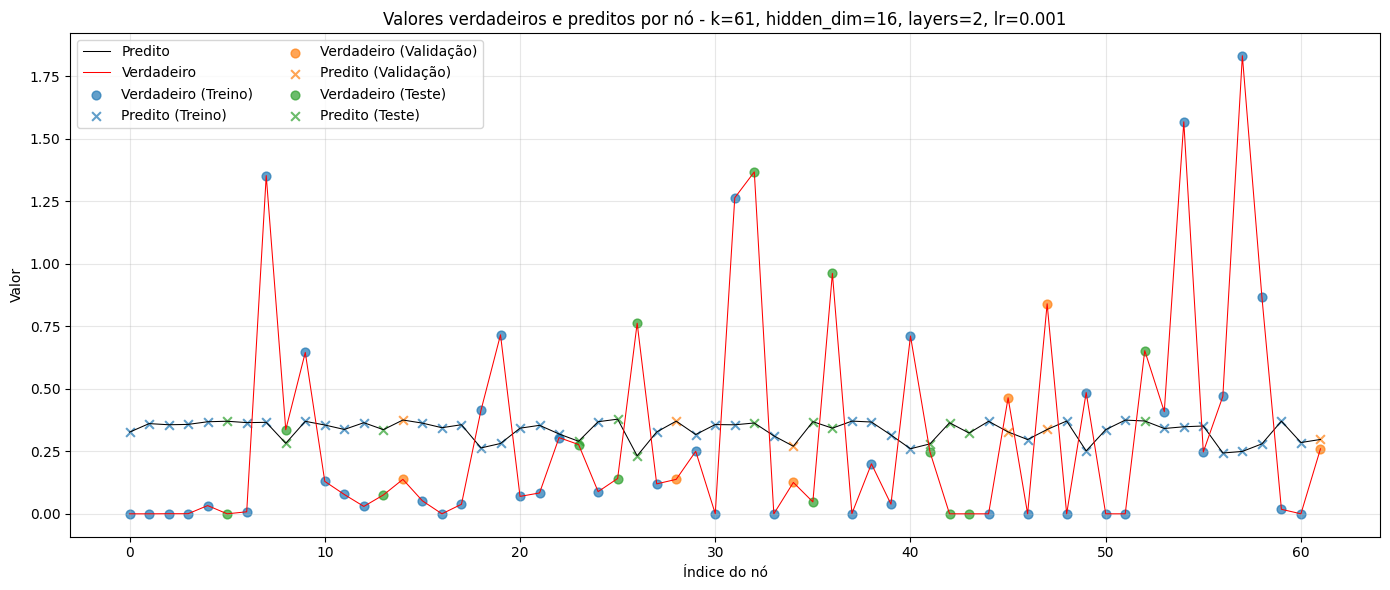

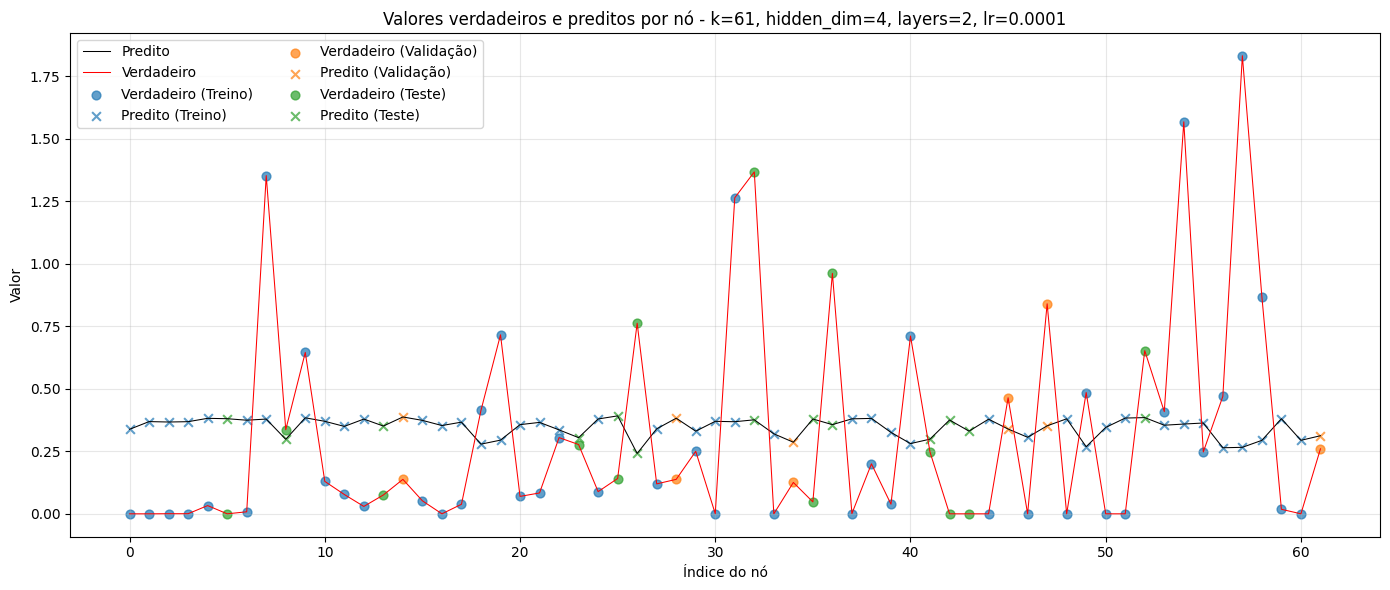

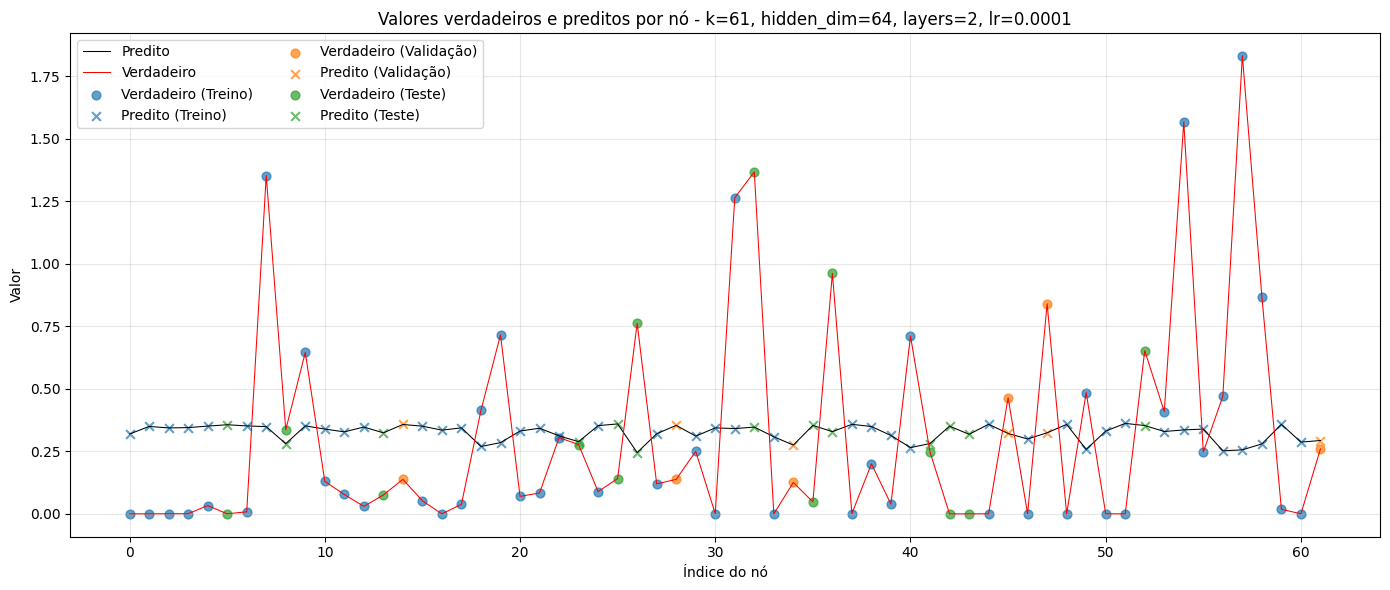

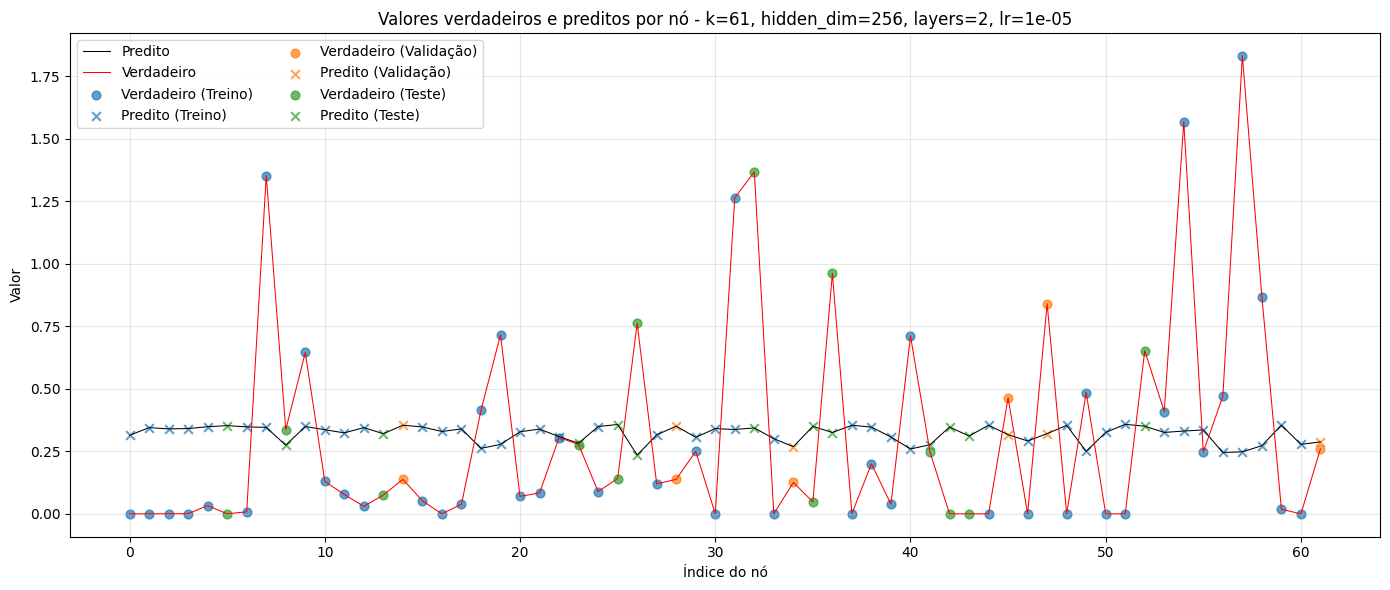

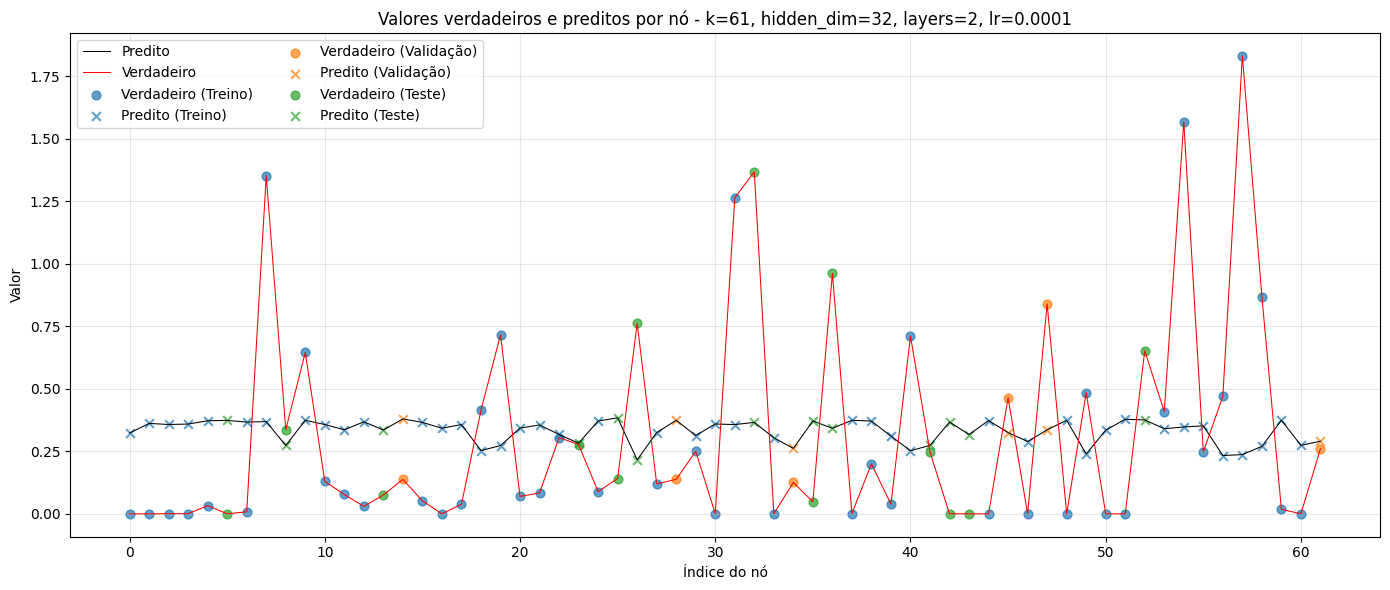

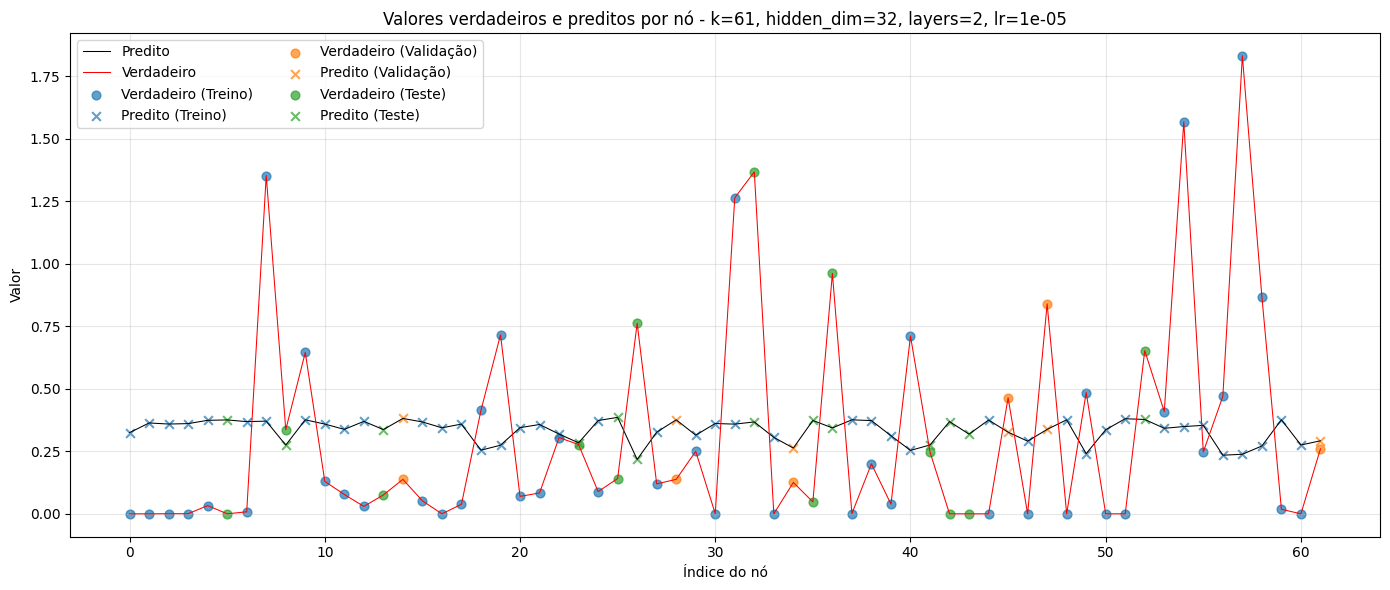

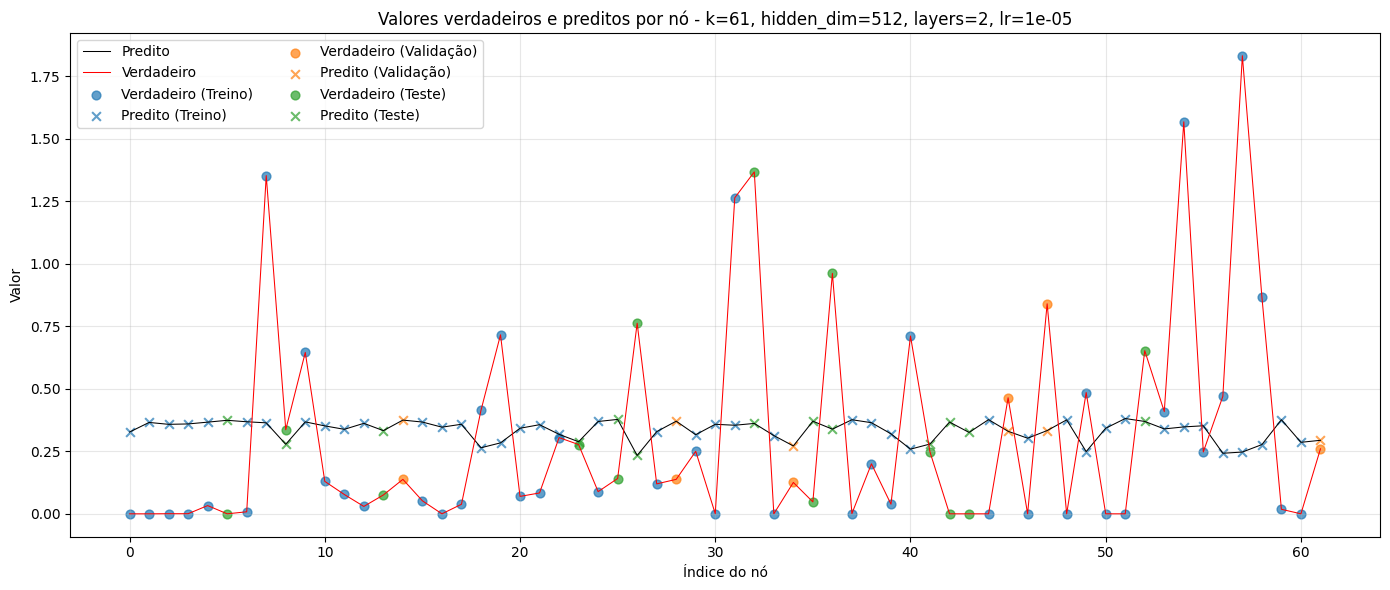

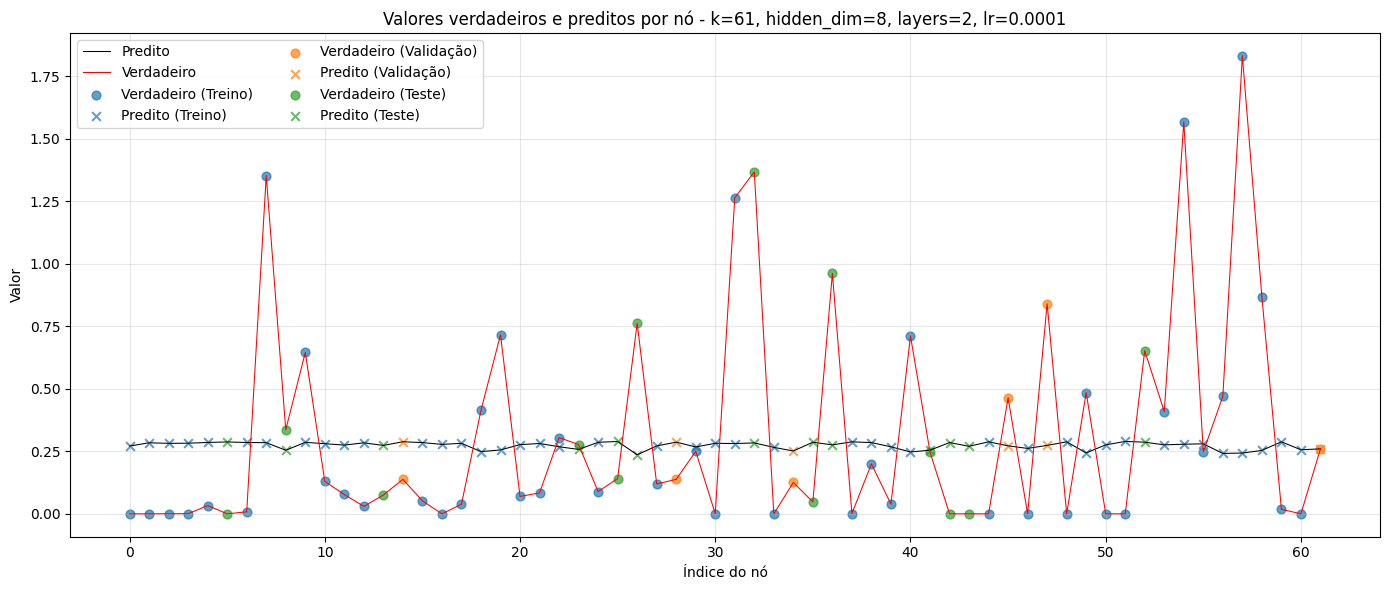

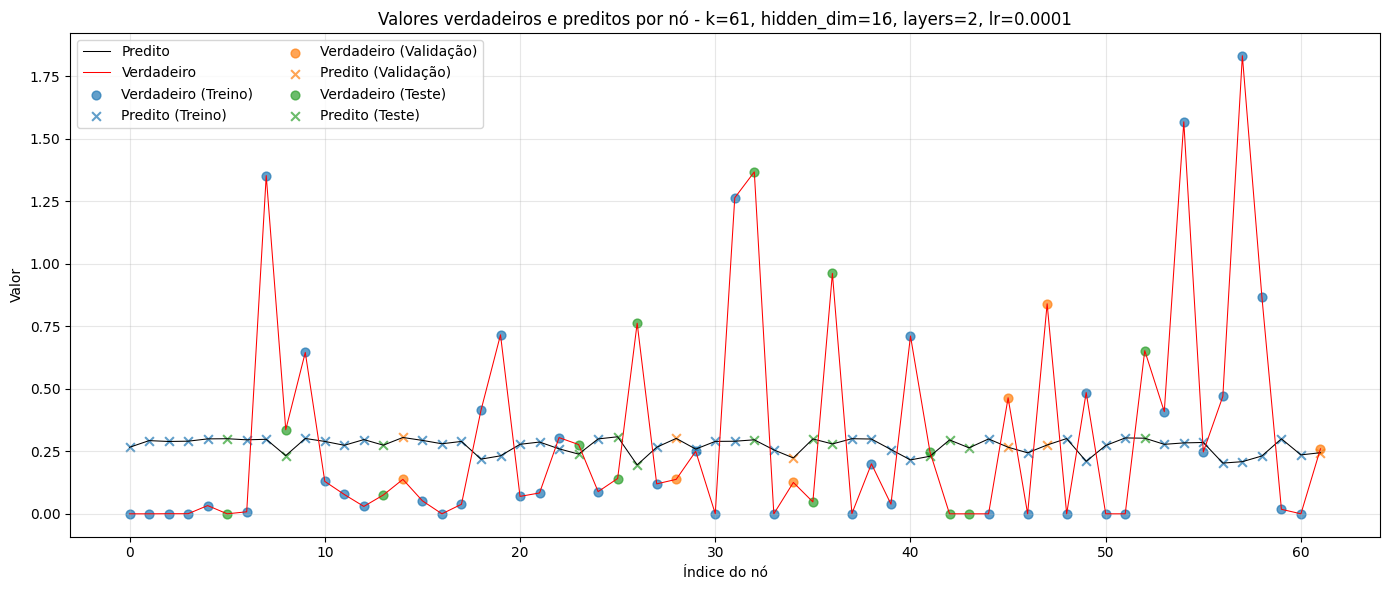

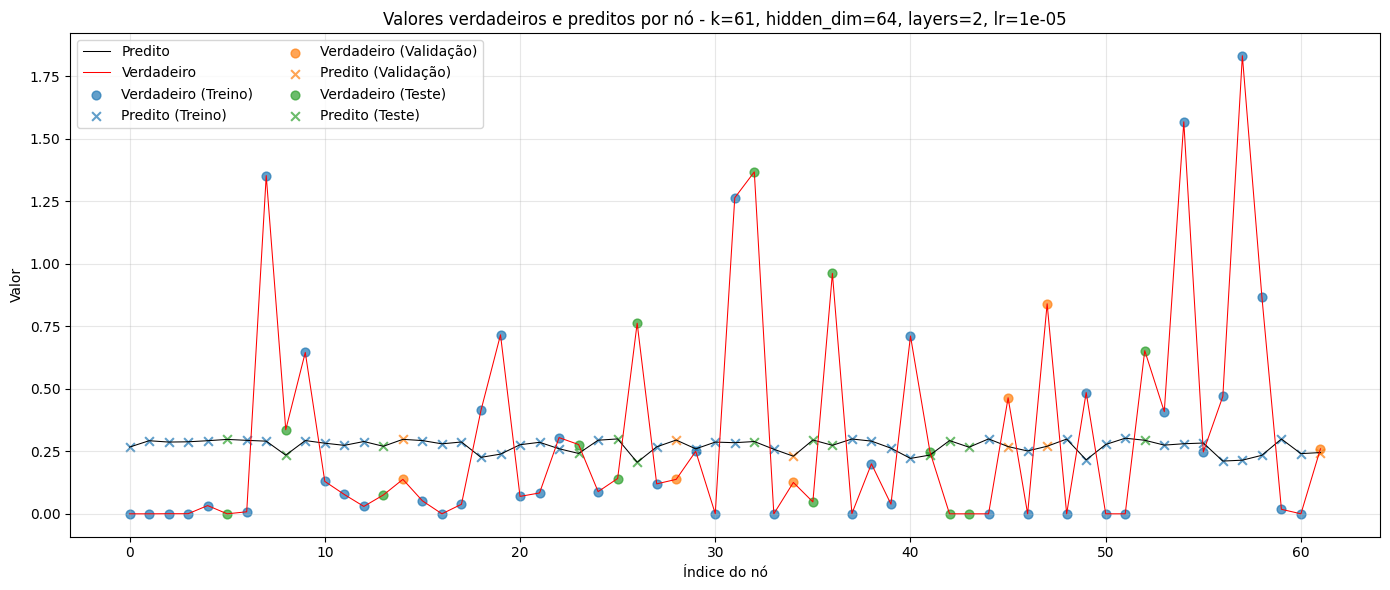

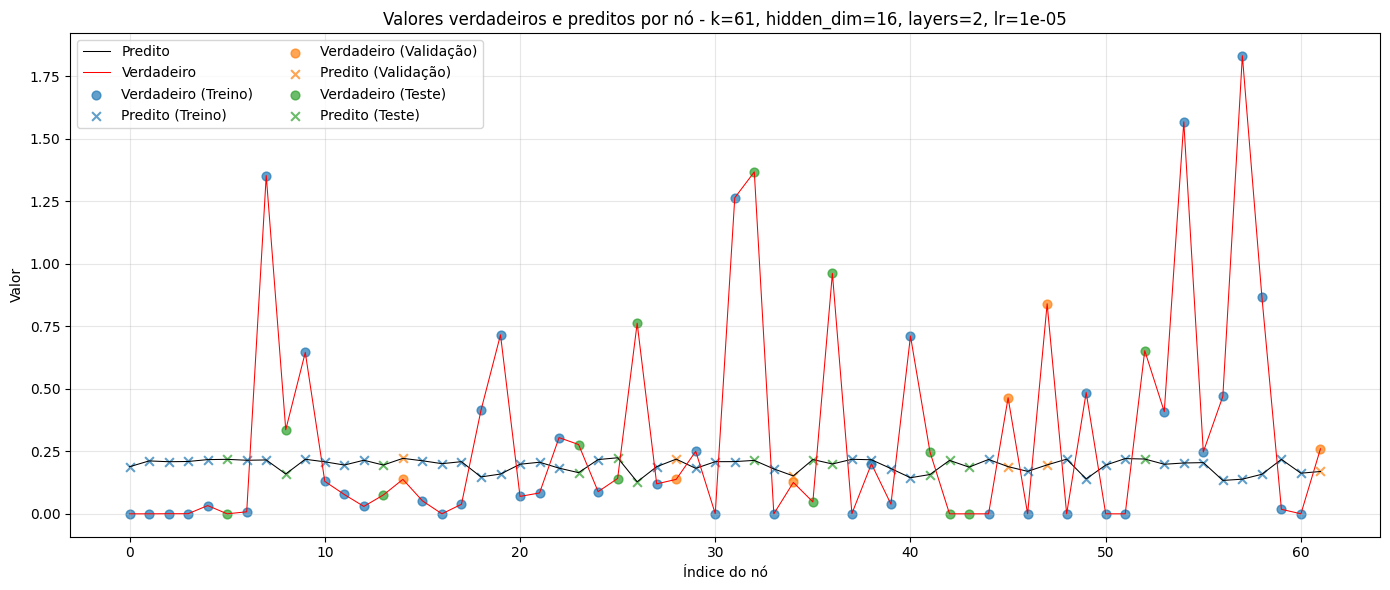

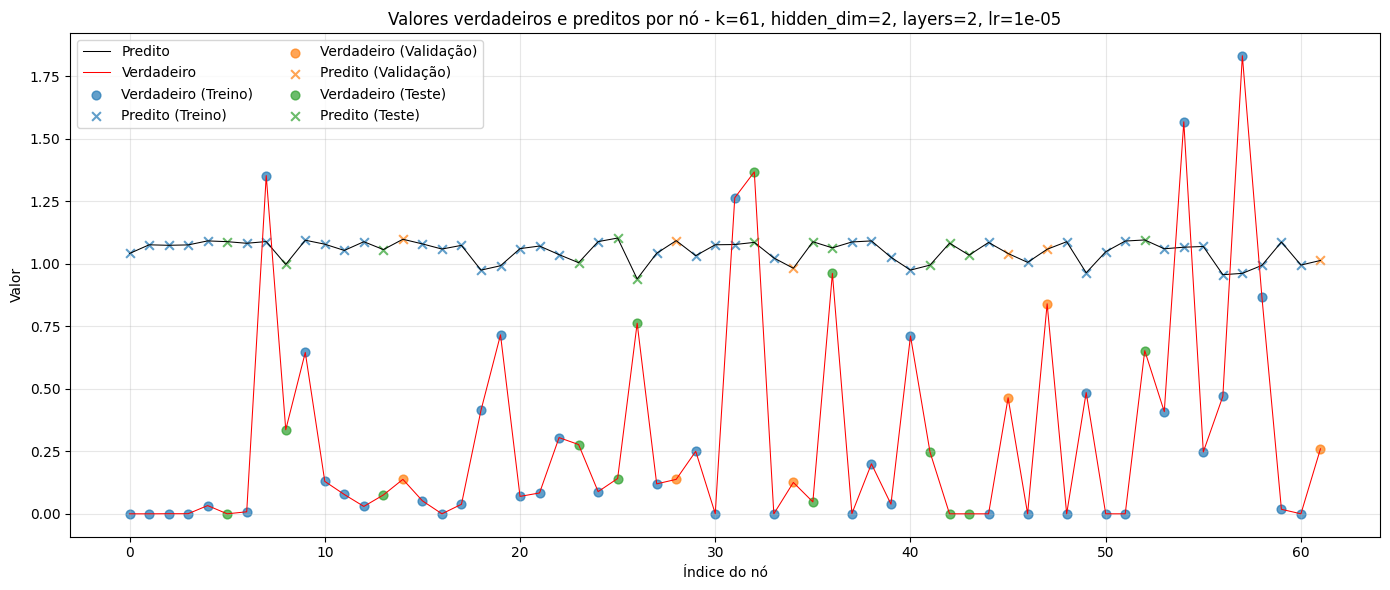

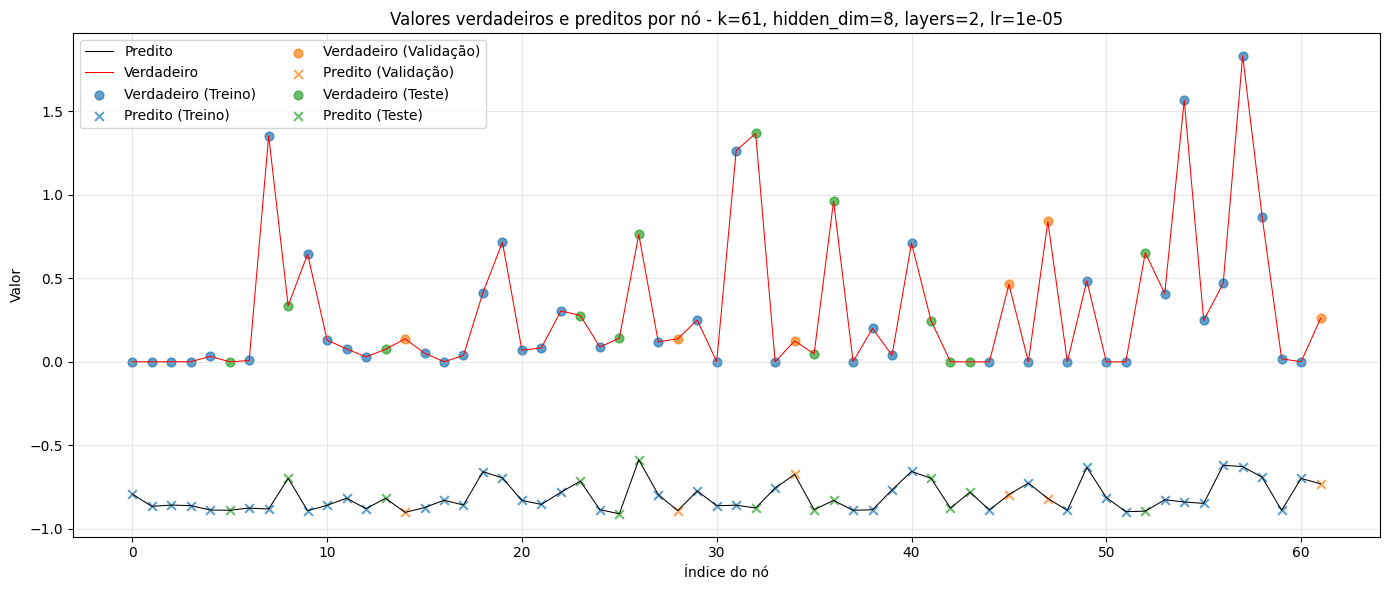

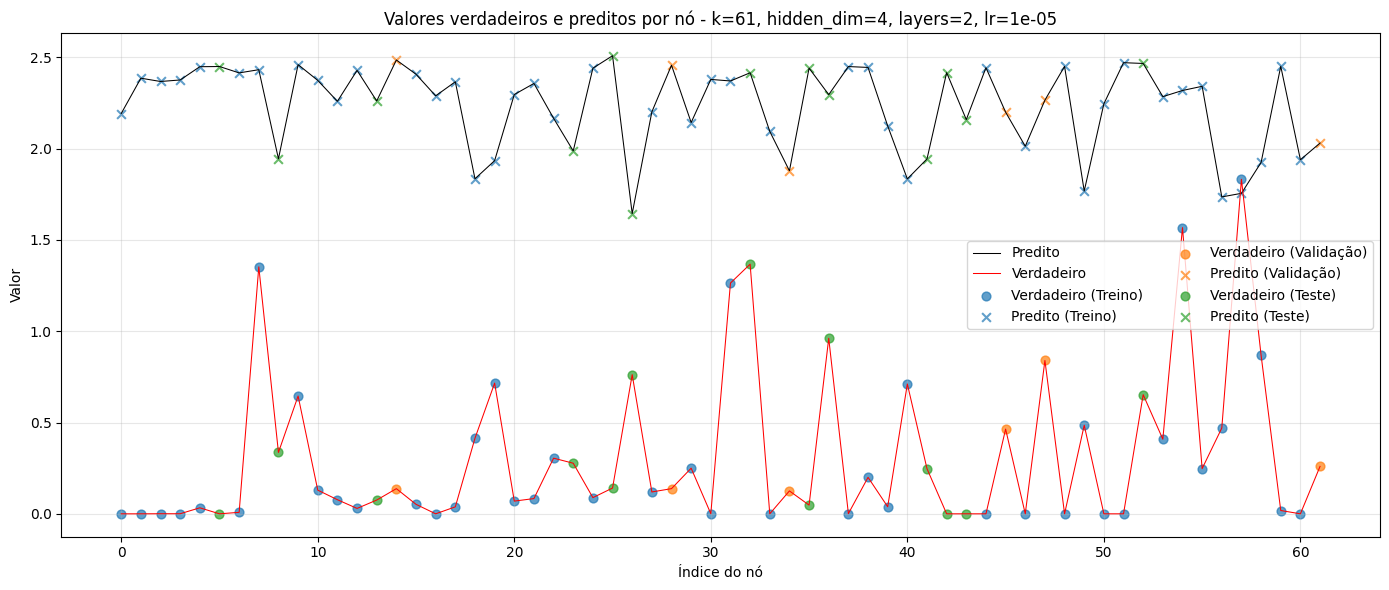

In [39]:
y_true = y.cpu().numpy()
idx_all = np.arange(len(y_true))

split_masks = {
    "Treino": mask_train,
    "Validação": mask_val,
    "Teste": mask_test,
}
colors = {
    "Treino": "tab:blue",
    "Validação": "tab:orange",
    "Teste": "tab:green",
}

def plot_predictions_by_node(ax, y_pred, row_dict, marker_size=40, legend_fontsize=10):
    ax.plot(
        idx_all,
        y_pred,
        color="black",
        linestyle="-",
        linewidth=0.75,
        label="Predito",
    )
    ax.plot(
        idx_all,
        y_true,
        color="red",
        linestyle="-",
        linewidth=0.75,
        label="Verdadeiro",
    )

    for label, mask in split_masks.items():
        node_idx = mask.nonzero(as_tuple=False).flatten().cpu().numpy()
        ax.scatter(
            node_idx,
            y_true[node_idx],
            color=colors[label],
            marker="o",
            s=marker_size,
            alpha=0.7,
            label=f"Verdadeiro ({label})",
        )
        ax.scatter(
            node_idx,
            y_pred[node_idx],
            color=colors[label],
            marker="x",
            s=marker_size,
            alpha=0.7,
            label=f"Predito ({label})",
        )

    ax.set_xlabel("Índice do nó")
    ax.set_ylabel("Valor")
    ax.set_title(
        "Valores verdadeiros e preditos por nó - "
        f"k={row_dict['k']}, hidden_dim={row_dict['hidden_dim']}, "
        f"layers={row_dict['n_hidden_layers']}, lr={row_dict['learning_rate']}"
    )
    ax.legend(ncol=2, fontsize=legend_fontsize)
    ax.grid(alpha=0.3)
    return ax


# Uma previsão por linha/configuração, na mesma ordem da tabela da Parte 7.
prediction_plot_rows = sorted(grid_rows, key=lambda row: row["loss_validation"])
for row_dict in prediction_plot_rows:
    history_key = tuple(row_dict[name] for name in grid_names)
    y_pred = grid_predictions_by_config[history_key]

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_predictions_by_node(ax, y_pred, row_dict)
    plt.tight_layout()
    plt.show()

In [40]:
y_true = y.cpu().numpy()
idx = np.arange(len(y_true))

for hidden_dim in sorted(grid_predictions_by_hidden_dim):
    y_pred = grid_predictions_by_hidden_dim[hidden_dim]
    node_losses = np.square(y_pred - y_true)

    df_node_results = pd.DataFrame(
        {
            "hidden_dim": [hidden_dim] * len(y_true),
            "Índice": idx,
            "Estação": estacoes,
            "Valor verdadeiro": y_true,
            "Valor predito": y_pred,
            "Loss por nó (MSE)": node_losses,
        }
    )

    print(f"hidden_dim = {hidden_dim}")
    display(df_node_results.style.format(precision=6))

hidden_dim = 2


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,2,0,ACEGUA,0.000000,1.040931,1.083538
1,2,1,ALEGRETE,0.000000,1.075545,1.156796
2,2,2,BAGE,0.000477,1.073629,1.151655
3,2,3,BAGE - CENTRO,0.000477,1.075158,1.154940
4,2,4,BENTO GONCALVES,0.032902,1.091213,1.120022
5,2,5,CACAPAVA DO SUL,0.000000,1.088112,1.183987
6,2,6,CACHOEIRA DO SUL,0.008106,1.081705,1.152614
7,2,7,CACHOEIRINHA,1.352310,1.088550,0.069569
8,2,8,CAMBARA DO SUL,0.336170,0.997199,0.436959
9,2,9,CAMPO BOM,0.645161,1.093973,0.201433


hidden_dim = 4


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,4,0,ACEGUA,0.000000,2.191944,4.804618
1,4,1,ALEGRETE,0.000000,2.385452,5.690382
2,4,2,BAGE,0.000477,2.367381,5.602233
3,4,3,BAGE - CENTRO,0.000477,2.375691,5.641643
4,4,4,BENTO GONCALVES,0.032902,2.448325,5.834269
5,4,5,CACAPAVA DO SUL,0.000000,2.449326,5.999198
6,4,6,CACHOEIRA DO SUL,0.008106,2.414419,5.790342
7,4,7,CACHOEIRINHA,1.352310,2.431912,1.165541
8,4,8,CAMBARA DO SUL,0.336170,1.943959,2.584985
9,4,9,CAMPO BOM,0.645161,2.459677,3.292469


hidden_dim = 8


...

,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,1024,0,ACEGUA,0.000000,0.326991,0.106923
1,1024,1,ALEGRETE,0.000000,0.350782,0.123048
2,1024,2,BAGE,0.000477,0.350910,0.122803
3,1024,3,BAGE - CENTRO,0.000477,0.351994,0.123564
4,1024,4,BENTO GONCALVES,0.032902,0.364668,0.110069
5,1024,5,CACAPAVA DO SUL,0.000000,0.361250,0.130502
6,1024,6,CACHOEIRA DO SUL,0.008106,0.356233,0.121192
7,1024,7,CACHOEIRINHA,1.352310,0.362068,0.980580
8,1024,8,CAMBARA DO SUL,0.336170,0.295823,0.001628
9,1024,9,CAMPO BOM,0.645161,0.366580,0.077607


hidden_dim = 2048


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,2048,0,ACEGUA,0.000000,0.277315,0.076903
1,2048,1,ALEGRETE,0.000000,0.140588,0.019765
2,2048,2,BAGE,0.000477,0.240040,0.057390
3,2048,3,BAGE - CENTRO,0.000477,0.236508,0.055711
4,2048,4,BENTO GONCALVES,0.032902,0.342034,0.095563
5,2048,5,CACAPAVA DO SUL,0.000000,0.187431,0.035130
6,2048,6,CACHOEIRA DO SUL,0.008106,0.188038,0.032375
7,2048,7,CACHOEIRINHA,1.352310,0.339249,1.026293
8,2048,8,CAMBARA DO SUL,0.336170,0.447517,0.012398
9,2048,9,CAMPO BOM,0.645161,0.359491,0.081607


hidden_dim = 4096


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,4096,0,ACEGUA,0.000000,0.271355,0.073634
1,4096,1,ALEGRETE,0.000000,0.130544,0.017042
2,4096,2,BAGE,0.000477,0.235893,0.055421
3,4096,3,BAGE - CENTRO,0.000477,0.232375,0.053777
4,4096,4,BENTO GONCALVES,0.032902,0.349926,0.100504
5,4096,5,CACAPAVA DO SUL,0.000000,0.180440,0.032559
6,4096,6,CACHOEIRA DO SUL,0.008106,0.181351,0.030014
7,4096,7,CACHOEIRINHA,1.352310,0.349234,1.006161
8,4096,8,CAMBARA DO SUL,0.336170,0.450096,0.012979
9,4096,9,CAMPO BOM,0.645161,0.370606,0.075380


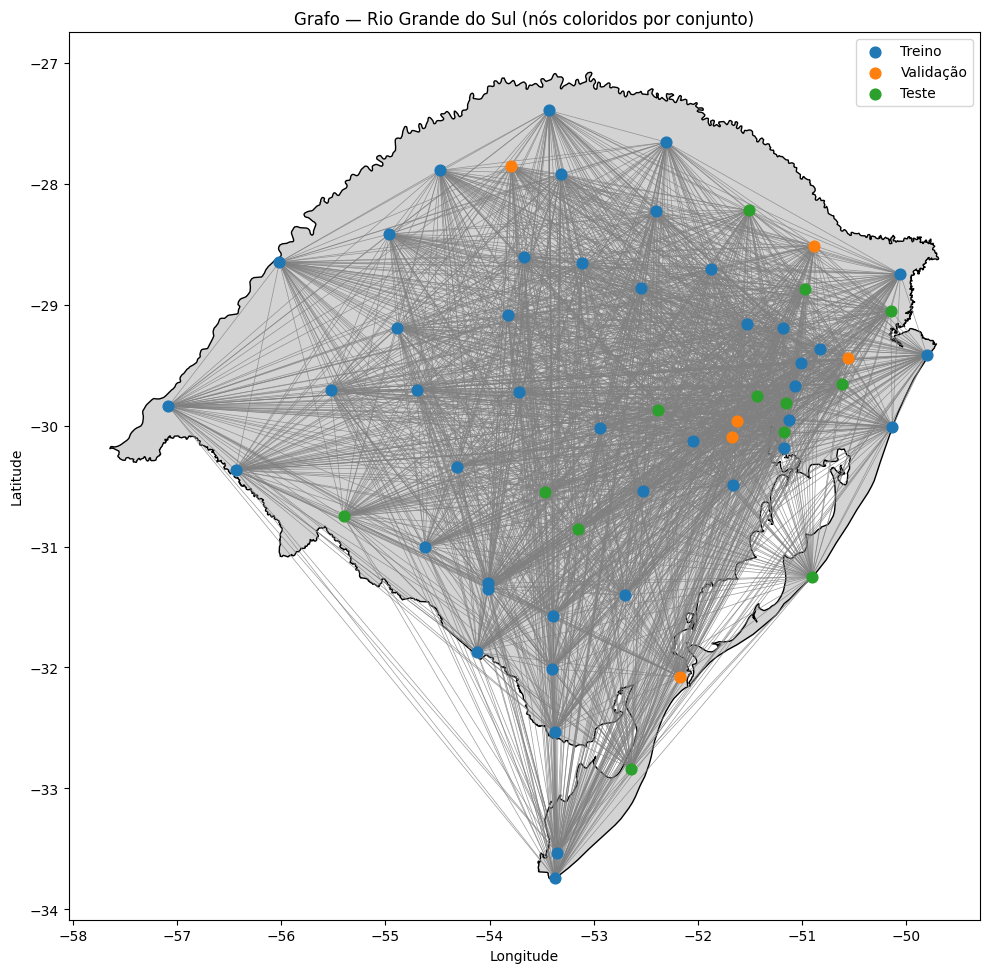

In [41]:
# Plot do grafo sobre o mapa do Rio Grande do Sul
# Nós coloridos por conjunto: Treino / Validação / Teste
colors_map = {'Treino':'tab:blue','Validação':'tab:orange','Teste':'tab:green'}
try:
    import geopandas as gpd
    # GeoJSON público com os estados do Brasil (usa GitHub)
    states = gpd.read_file(
        'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
    )
    rs = states[states['name'].str.contains('Rio Grande do Sul', case=False, na=False)]

    df_nodes = pd.DataFrame({
        'lon': coords[:, 1],
        'lat': coords[:, 0],
        'Conjunto': [ 'Treino' if mask_train[i].item() else ('Validação' if mask_val[i].item() else 'Teste') for i in range(len(coords)) ],
    })
    gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry=gpd.points_from_xy(df_nodes.lon, df_nodes.lat), crs='EPSG:4326')

    fig, ax = plt.subplots(figsize=(10,10))
    if not rs.empty:
        rs.plot(ax=ax, color='lightgray', edgecolor='black')

    # linhas das arestas (usar A_weighted para espessura/alpha)
    A = (A_weighted.cpu().numpy() > 0).astype(float)
    Nn = A.shape[0]
    for i in range(Nn):
        for j in range(i+1, Nn):
            w = A[i, j]
            if w > 0 and not np.isclose(w, 0):
                xs = [coords[i,1], coords[j,1]]
                ys = [coords[i,0], coords[j,0]]
                ax.plot(xs, ys, color='gray', linewidth=0.5, alpha=min(0.8, 0.3 + 0.7 * w))

    # plot dos nós por conjunto
    for label, color in colors_map.items():
        subset = gdf_nodes[gdf_nodes['Conjunto'] == label]
        subset.plot(ax=ax, color=color, markersize=60, label=label, zorder=3)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Grafo — Rio Grande do Sul (nós coloridos por conjunto)')
    ax.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Não foi possível carregar mapa externo — plotando sem mapa. Erro:', e)
    fig, ax = plt.subplots(figsize=(10,8))
    A = (A_weighted.cpu().numpy() > 0).astype(float)
    Nn = A.shape[0]
    for i in range(Nn):
        for j in range(i+1, Nn):
            w = A[i, j]
            if w > 0 and not np.isclose(w, 0):
                xs = [coords[i,1], coords[j,1]]
                ys = [coords[i,0], coords[j,0]]
                ax.plot(xs, ys, color='gray', linewidth=0.5, alpha=min(0.8, 0.3 + 0.7 * w))

    # desenhar nós separados por conjunto
    for label, color in colors_map.items():
        idx = [i for i in range(len(coords)) if (mask_train[i].item() and label == 'Treino') or (mask_val[i].item() and label == 'Validação') or (mask_test[i].item() and label == 'Teste')]
        if len(idx) > 0:
            ax.scatter(coords[idx,1], coords[idx,0], c=color, s=60, label=label, edgecolor='k', zorder=3)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Grafo — (sem mapa)')
    ax.legend()
    plt.tight_layout()
    plt.show()


colocar uma tonalidade na aresta baseada em seu peso

In [42]:
# Tabela completa de precipitação para um nó específico em todas as datas
node_id = node_index  # Ajuste para outro nó, se desejar
precip_node = X_tp.squeeze(-1).cpu().numpy()[:, node_id]

date_index = None
try:
    date_index = pd.to_datetime(tp_daily_dataset.time.values)
except Exception:
    date_index = pd.date_range(start_date, periods=precip_node.shape[0], freq="D")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(f"Nó selecionado: {node_id} ({estacoes[node_id]})")
df_precip_node = pd.DataFrame(
    {"Precipitação (mm)": precip_node},
    index=pd.Index(date_index, name="data"),
)

display(df_precip_node)


Nó selecionado: 32 (PORTO ALEGRE - JARDIM BOTANICO)


,Precipitação (mm)
data,
2024-01-01,0.102043
2024-01-02,10.678291
2024-01-03,1.441479
2024-01-04,0.726223
2024-01-05,0.775814
2024-01-06,0.124931
2024-01-07,1.220703
2024-01-08,0.230312
2024-01-09,2.810955


In [43]:
from matplotlib.backends.backend_pdf import PdfPages
# Nome identificador da função de peso usada
weight_name = "gaussiana"

# Formata a data como YYYY-MM-DD
date_name = pd.Timestamp(target_date).strftime("%Y-%m-%d")

def export_grid_results_report(
    output_dir=None,
    pdf_name = f"WeightedEdges_{date_name}_{weight_name}.pdf",
    tex_name = f"WeightedEdges_{date_name}_{weight_name}.tex"
):
    output_dir = (
        Path(output_dir).resolve()
        if output_dir is not None
        else project_dir / "Results" / "WeightedEdges_report"
    )
    images_dir = output_dir / "images"
    output_dir.mkdir(parents=True, exist_ok=True)
    images_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = output_dir / pdf_name
    tex_path = output_dir / tex_name

    y_true = y.cpu().numpy()
    idx_all = np.arange(len(y_true))

    split_masks = {
        "Treino": mask_train,
        "Validação": mask_val,
        "Teste": mask_test,
    }
    colors = {
        "Treino": "tab:blue",
        "Validação": "tab:orange",
        "Teste": "tab:green",
    }
    table_keys = [
        "k",
        "epochs",
        "hidden_dim",
        "n_hidden_layers",
        "learning_rate",
        "best_epoch",
        "stop_epoch",
        "loss_train",
        "loss_validation",
        "loss_test",
    ]

    def format_value(key, value):
        if key in {"k", "epochs", "hidden_dim", "n_hidden_layers", "best_epoch", "stop_epoch"}:
            return str(int(value))
        if key == "learning_rate":
            return f"{value:.3g}"
        return f"{value:.6f}"

    def build_page_figure(row_dict, history_run, y_pred, ix):
        # Uma figura A4 completa: a mesma página é usada no PDF e no LaTeX.
        fig = plt.figure(figsize=(8.27, 11.69), layout="constrained")
        gs = fig.add_gridspec(
            nrows=3, ncols=1, height_ratios=[1.15, 3.1, 3.5], hspace=0.08
        )

        ax_table = fig.add_subplot(gs[0, 0])
        ax_loss = fig.add_subplot(gs[1, 0])
        ax_pred = fig.add_subplot(gs[2, 0])

        ax_table.axis("off")
        half = (len(table_keys) + 1) // 2
        table_data = []
        for pos in range(half):
            left_key = table_keys[pos]
            right_pos = pos + half
            row = [
                left_key.replace("_", " "),
                format_value(left_key, row_dict[left_key]),
            ]
            if right_pos < len(table_keys):
                right_key = table_keys[right_pos]
                row.extend([
                    right_key.replace("_", " "),
                    format_value(right_key, row_dict[right_key]),
                ])
            else:
                row.extend(["", ""])
            table_data.append(row)

        result_table = ax_table.table(
            cellText=table_data,
            colLabels=["Parâmetro", "Valor", "Parâmetro", "Valor"],
            colWidths=[0.29, 0.18, 0.29, 0.18],
            cellLoc="center",
            loc="center",
            bbox=[0.0, 0.0, 1.0, 0.86],
        )
        result_table.auto_set_font_size(False)
        result_table.set_fontsize(8.5)
        for col in range(4):
            result_table[(0, col)].set_facecolor("#d9e8f5")
            result_table[(0, col)].set_text_props(weight="bold")
        ax_table.set_title(
            f"Configuração {ix + 1} - linha da tabela ordenada por loss de validação",
            fontsize=11,
            weight="bold",
            pad=4,
        )

        epochs_executed = range(len(history_run["train"]))
        ax_loss.plot(epochs_executed, history_run["train"], label="Treino")
        ax_loss.plot(epochs_executed, history_run["validation"], label="Validação")
        ax_loss.plot(epochs_executed, history_run["test"], label="Teste")
        ax_loss.axvline(
            row_dict["stop_epoch"],
            color="gray",
            linestyle="--",
            label=f"Parada: {row_dict['stop_epoch']}",
        )
        ax_loss.set(
            title=(
                "Weighted GNN - configuração: "
                f"k={row_dict['k']}, hidden={row_dict['hidden_dim']}, "
                f"lr={row_dict['learning_rate']}"
            ),
            xlabel="Época",
            ylabel="MSE Loss",
        )
        ax_loss.grid(alpha=0.3)
        ax_loss.legend(fontsize=8)

        # Chama exatamente a mesma função usada pelo gráfico da Parte 7.
        plot_predictions_by_node(
            ax_pred, y_pred, row_dict, marker_size=40, legend_fontsize=7
        )
        return fig

    with PdfPages(pdf_path) as pdf_file, open(tex_path, "w", encoding="utf-8") as tex_file:
        tex_file.write(
            "\\documentclass[a4paper]{article}\n"
            "\\usepackage[margin=8mm]{geometry}\n"
            "\\usepackage{graphicx}\n"
            "\\pagestyle{empty}\n"
            "\\setlength{\\parindent}{0pt}\n"
            "\\begin{document}\n"
        )

        # A Parte 7 exibe a tabela nesta ordem.
        report_rows = sorted(grid_rows, key=lambda row: row["loss_validation"])

        for ix, row_dict in enumerate(report_rows):
            history_key = tuple(row_dict[name] for name in grid_names)
            history_run = grid_histories[history_key]
            y_pred = grid_predictions_by_config[history_key]

            fig = build_page_figure(row_dict, history_run, y_pred, ix)
            pdf_file.savefig(fig)
            page_stem = f"config_{ix + 1:03d}_page"
            page_pdf_path = images_dir / f"{page_stem}.pdf"
            page_png_path = images_dir / f"{page_stem}.png"
            fig.savefig(page_pdf_path, format="pdf")
            fig.savefig(page_png_path, dpi=180)
            plt.close(fig)

            if ix > 0:
                tex_file.write("\\clearpage\n")
            # Inclui a página vetorial completa: tabela e gráficos nunca se separam.
            tex_file.write(
                "\\noindent\\includegraphics"
                "[width=\\textwidth,height=\\textheight,keepaspectratio]"
                f"{{images/{page_stem}.pdf}}\n"
            )

        tex_file.write("\\end{document}\n")

    print(f"Relatório PDF salvo em: {pdf_path}")
    print(f"Arquivo LaTeX salvo em: {tex_path}")


# Executar exportação automaticamente se desejar.
export_grid_results_report()


Relatório PDF salvo em: C:\Users\loren\GNNGCN-proj\Results\WeightedEdges_report\WeightedEdges_2025-01-12_gaussiana.pdf
Arquivo LaTeX salvo em: C:\Users\loren\GNNGCN-proj\Results\WeightedEdges_report\WeightedEdges_2025-01-12_gaussiana.tex


In [44]:
# Melhor configuração pelo menor MSE médio considerando todos os nós.
# Atenção: esta análise inclui os nós de treino, validação e teste.

y_true_all_nodes = y.detach().cpu().numpy()
global_mse_rows = []

for row_dict in grid_rows:
    config_key = tuple(
        row_dict[name]
        for name in grid_names
    )

    y_pred_config = np.asarray(
        grid_predictions_by_config[config_key]
    )

    # Para cada nó: (predito - verdadeiro)²
    mse_by_node = np.square(
        y_pred_config - y_true_all_nodes
    )

    global_mse_rows.append({
        **row_dict,
        "mse_mean_all_nodes": float(mse_by_node.mean()),
    })


# Tabela ordenada do menor para o maior MSE médio
global_mse_results = (
    pd.DataFrame(global_mse_rows)
    .sort_values("mse_mean_all_nodes")
    .reset_index(drop=True)
)


# Configuração com menor MSE médio
best_global_mse_run = min(
    global_mse_rows,
    key=lambda row: row["mse_mean_all_nodes"],
)

best_global_mse_config = {
    name: best_global_mse_run[name]
    for name in grid_names
}

best_global_mse_key = tuple(
    best_global_mse_config[name]
    for name in grid_names
)

best_global_mse_predictions = np.asarray(
    grid_predictions_by_config[best_global_mse_key]
)


# Resultado individual dos nós para a melhor configuração
best_global_mse_by_node = pd.DataFrame({
    "Índice": np.arange(len(y_true_all_nodes)),
    "Estação": estacoes,
    "Valor verdadeiro": y_true_all_nodes,
    "Valor predito": best_global_mse_predictions,
    "MSE do nó": np.square(
        best_global_mse_predictions - y_true_all_nodes
    ),
})


print("Configurações ordenadas pelo MSE médio de todos os nós:")

display(
    global_mse_results.style.format({
        "learning_rate": "{:.6g}",
        "loss_train": "{:.6f}",
        "loss_validation": "{:.6f}",
        "loss_test": "{:.6f}",
        "mse_mean_all_nodes": "{:.6f}",
    })
)


print("\nMelhor configuração global:")

for name, value in best_global_mse_config.items():
    print(f"{name}: {value}")

print(
    "\nMSE médio de todos os nós: "
    f"{best_global_mse_run['mse_mean_all_nodes']:.6f}"
)


print("\nMSE individual dos nós da melhor configuração:")

display(
    best_global_mse_by_node.style.format({
        "Valor verdadeiro": "{:.6f}",
        "Valor predito": "{:.6f}",
        "MSE do nó": "{:.6f}",
    })
)

Configurações ordenadas pelo MSE médio de todos os nós:


,k,epochs,hidden_dim,n_hidden_layers,learning_rate,best_epoch,stop_epoch,loss_train,loss_validation,loss_test,mse_mean_all_nodes
0,61,2000,512,2,0.001,1417,2000,0.165060,0.059311,0.150181,0.151706
1,61,2000,4096,2,1e-05,1446,2000,0.166760,0.058438,0.153480,0.153492
2,61,2000,4096,2,0.0001,921,1921,0.169158,0.058482,0.153349,0.155133
3,61,2000,512,2,0.0001,1407,2000,0.168400,0.059982,0.155812,0.155268
4,61,2000,2048,2,1e-05,1695,2000,0.168586,0.058898,0.156011,0.155334
5,61,2000,256,2,0.001,1073,2000,0.170051,0.062060,0.157305,0.156928
6,61,2000,1024,2,0.0001,933,1933,0.170606,0.059062,0.157277,0.157017
7,61,2000,2048,2,0.0001,832,1832,0.170640,0.058722,0.157548,0.157064
8,61,2000,32,2,0.001,734,1734,0.171573,0.062833,0.159034,0.158421
9,61,2000,256,2,0.0001,1703,2000,0.172049,0.061388,0.159041,0.158612



Melhor configuração global:
k: 61
epochs: 2000
hidden_dim: 512
n_hidden_layers: 2
learning_rate: 0.001

MSE médio de todos os nós: 0.151706

MSE individual dos nós da melhor configuração:


,Índice,Estação,Valor verdadeiro,Valor predito,MSE do nó
0,0,ACEGUA,0.000000,0.276355,0.076372
1,1,ALEGRETE,0.000000,0.138667,0.019228
2,2,BAGE,0.000477,0.239779,0.057266
3,3,BAGE - CENTRO,0.000477,0.236395,0.055657
4,4,BENTO GONCALVES,0.032902,0.351774,0.101680
5,5,CACAPAVA DO SUL,0.000000,0.182581,0.033336
6,6,CACHOEIRA DO SUL,0.008106,0.186386,0.031784
7,7,CACHOEIRINHA,1.352310,0.357100,0.990444
8,8,CAMBARA DO SUL,0.336170,0.454566,0.014018
9,9,CAMPO BOM,0.645161,0.374741,0.073127


## Referência do self-tuning:

Zelnik-Manor, L., & Perona, P. (2004). "Self-Tuning Spectral Clustering." NIPS.

## Próximos passos:

neuronios por loss;
testar outras funções de peso, além da exponencial;
comparar o modelo otimizado de um tipo de peso com o modelo otimizado com outro tipo de peso;